# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Import train test split
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import classification_report, accuracy_score, f1_score, r2_score, root_mean_squared_error

# Import KFold
from sklearn.model_selection import KFold

# Import log2
import math

# Import pprint
from pprint import pprint

# Import SMOTE
from imblearn.over_sampling import SMOTE

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
oaa_ridge_forward_features = ['Parent tweets',
 'Replies to parents',
 'Parent tweets with replies',
 'Toxic parent tweets',
 'Toxic replies',
 'Toxic replies to non-toxic parents',
 'Toxic replies to toxic parents',
 'Friends_count',
 'Listed_count',
 'Verified',
 'Statuses_count',
 'Retweet_count avg',
 'Retweet_count max',
 'Favorite_count min',
 'Repliers with min 1 toxic reply',
 'High toxicity parents',
 'High identity_attack parents',
 'High insult parents',
 'High profanity parents',
 'High threat parents',
 'High toxicity replies',
 'High identity_attack replies',
 'High insult replies',
 'High profanity replies',
 'High threat replies',
 '<3 replies parents',
 '>=3 replies parents',
 'Love',
 'Feminist',
 'Toxicity']

In [3]:
# Import the datasets
convabuse = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/convabuse_imbalanced.csv')
dynamically_generated_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_imbalanced.csv')
online_abusive_attacks = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_class_imbalanced.csv')
us_elections_2020_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/us_elections_2020_hate_speech_imbalanced.csv')
mlma_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/MLMA_hate_speech_imbalanced.csv')

In [4]:
convabuse.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,7,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,1,0
2,7,0,0,0,0,0,0,0,0
3,7,1,0,0,0,0,0,0,0
4,7,0,0,0,0,0,0,0,0


In [5]:
convabuse_X = convabuse.drop("abuse_level", axis=1)
convabuse_y = convabuse["abuse_level"]

In [6]:
dynamically_generated_hate_speech.head()

,label,type,annotator,target_groups,original
0,1.0,0,3,0,1
1,1.0,0,3,0,1
2,1.0,0,18,0,1
3,1.0,0,16,0,1
4,1.0,0,7,0,1


In [7]:
dghs_X = dynamically_generated_hate_speech.drop("label", axis=1)
dghs_y = dynamically_generated_hate_speech["label"]

In [8]:
online_abusive_attacks.head()

,Toxic parent tweets,Toxic replies,Toxic Level
0,0.0,0.0,0
1,67.0,13.0,2
2,28.0,45.0,2
3,47.0,49.0,2
4,97.0,7.0,3


In [9]:
oaa_X = online_abusive_attacks.drop("Toxic Level", axis=1)
oaa_y = online_abusive_attacks["Toxic Level"]

In [10]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,1,0,1,0
1,1,0,1,0
2,-1,0,1,0
3,0,0,1,0
4,0,1,1,0


In [11]:
us2020hs_X = us_elections_2020_hate_speech.drop("HOF", axis=1)
us2020hs_y = us_elections_2020_hate_speech["HOF"]

In [12]:
mlma_hate_speech.head()

,implicit,explicit,target_groups,annotator_sentiment,abuse_level
0,1,0,1,2,2
1,1,0,0,6,1
2,1,0,0,0,1
3,0,1,1,0,1
4,1,0,1,0,1


In [13]:
mlma_hate_speech_X = mlma_hate_speech.drop(columns=["target_groups"], axis=1)
mlma_hate_speech_y = mlma_hate_speech["target_groups"]

# Linear Modeling

In [14]:
# Get only the numeric features for each dataset
convabuse_X_numeric = convabuse_X.select_dtypes(include=np.number)
dghs_X_numeric = dghs_X.select_dtypes(include=np.number)
oaa_X_numeric = oaa_X.select_dtypes(include=np.number)
us2020hs_X_numeric = us2020hs_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric = mlma_hate_speech_X.select_dtypes(include=np.number)

In [15]:
# Use standard scaler on the Convabuse data
convabuse_scaler = StandardScaler()
convabuse_X_scaled = convabuse_scaler.fit_transform(convabuse_X_numeric)
convabuse_X_scaled = pd.DataFrame(convabuse_X_scaled, columns=convabuse_X_numeric.columns)

In [16]:
# Use standard scaler on the Dynamically Generated Hate Speech X data
dghs_scaler = StandardScaler()
dghs_X_scaled = dghs_scaler.fit_transform(dghs_X_numeric)
dghs_X_scaled = pd.DataFrame(dghs_X_scaled, columns=dghs_X_numeric.columns)

In [17]:
# Use standard scaler on the Online Abusive Attacks X data
oaa_scaler = StandardScaler()
oaa_X_scaled = oaa_scaler.fit_transform(oaa_X_numeric)
oaa_X_scaled = pd.DataFrame(oaa_X_scaled, columns=oaa_X_numeric.columns)

In [18]:
# Use standard scaler on the US elections 2020 hate speech X data
us2020hs_scaler = StandardScaler()
us2020hs_X_scaled = us2020hs_scaler.fit_transform(us2020hs_X_numeric)
us2020hs_X_scaled = pd.DataFrame(us2020hs_X_scaled, columns=us2020hs_X_numeric.columns)

In [19]:
# Use standard scaler on the MLMA hate speech X data
mlma_hate_speech_scaler = StandardScaler()
mlma_hate_speech_X_scaled = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_numeric)
mlma_hate_speech_X_scaled = pd.DataFrame(mlma_hate_speech_X_scaled, columns=mlma_hate_speech_X_numeric.columns)

In [20]:
for columns in [convabuse_X_numeric.columns, dghs_X_numeric.columns, oaa_X_numeric.columns, us2020hs_X_numeric.columns, mlma_hate_speech_X_numeric]:
  print(columns)

Index(['annotator_id', 'bot', 'generalised', 'individual', 'system',
       'explicit', 'implicit', 'target_groups'],
      dtype='object')
Index(['type', 'annotator', 'target_groups', 'original'], dtype='object')
Index(['Toxic parent tweets', 'Toxic replies'], dtype='object')
Index(['Trump', 'Biden', 'West'], dtype='object')
       implicit  explicit  annotator_sentiment  abuse_level
0             1         0                    2            2
1             1         0                    6            1
2             1         0                    0            1
3             0         1                    0            1
4             1         0                    0            1
...         ...       ...                  ...          ...
18655         1         0                    1            1
18656         0         1                    0            2
18657         0         1                    7            1
18658         1         0                    0            1
18659       

In [21]:
# Implement SMOTE to each dataset
smote = SMOTE(random_state=42)

convabuse_X_resampled, convabuse_y_resampled = smote.fit_resample(convabuse_X_scaled, convabuse_y)
dghs_X_resampled, dghs_y_resampled = smote.fit_resample(dghs_X_scaled, dghs_y)
oaa_X_resampled, oaa_y_resampled = smote.fit_resample(oaa_X_scaled, oaa_y)
us2020hs_X_resampled, us2020hs_y_resampled = smote.fit_resample(us2020hs_X_scaled, us2020hs_y)
mlma_hate_speech_X_resampled, mlma_hate_speech_y_resampled = smote.fit_resample(mlma_hate_speech_X_scaled, mlma_hate_speech_y)

In [22]:
# Train test split for each dataset
convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test = train_test_split(convabuse_X_resampled, convabuse_y_resampled, test_size=0.2, random_state=42, stratify=convabuse_y_resampled)
dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test = train_test_split(dghs_X_resampled, dghs_y_resampled, test_size=0.2, random_state=42, stratify=dghs_y_resampled)
oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test = train_test_split(oaa_X_resampled, oaa_y_resampled, test_size=0.2, random_state=42, stratify=oaa_y_resampled)
us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test = train_test_split(us2020hs_X_resampled, us2020hs_y_resampled, test_size=0.2, random_state=42, stratify=us2020hs_y_resampled)
mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test = train_test_split(mlma_hate_speech_X_resampled, mlma_hate_speech_y_resampled, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y_resampled)

In [23]:
# Get the max iteration based on log 2
convabuse_max_iter = int(np.ceil(np.log2(len(convabuse_X_train))))
dghs_max_iter = int(np.ceil(np.log2(len(dghs_X_train))))
oaa_max_iter = int(np.ceil(np.log2(len(oaa_X_train))))
us2020hs_max_iter = int(np.ceil(np.log2(len(us2020hs_X_train))))
mlma_hate_speech_max_iter = int(np.ceil(np.log2(len(mlma_hate_speech_X_train))))

In [24]:
svm_classification_results_list = []
svm_regression_results_list = []

In [25]:
# Setup KFold for each dataset's model
convabuse_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
dghs_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
oaa_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
us2020hs_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
mlma_hate_speech_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [26]:
# Loop through the parameter grid and train the SVM model
def svm_grid_search(X_train, X_test, y_train, y_test, param_grid, kfold, model_name):
    """Train an SVM model using GridSearchCV and print the classification report."""
    # Create the SVM model
    svm_model = svm.SVC()

    # Create the GridSearchCV object
    grid_search = GridSearchCV(svm_model, param_grid, cv=kfold, scoring='accuracy', verbose=1, n_jobs=-1)

    # Fit the model
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_

    # Make predictions on the test set
    y_pred = best_model.predict(X_test)

    # Print out the parameters that were tested:
    print(f"Parameters tested for {model_name}:")
    pprint(grid_search.cv_results_['params'])

    # Print the classification report
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    print("Classification report:")
    print(classification_report(y_test, y_pred))
    print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    return grid_search, best_model # Return the grid_search object

In [27]:
balance = "SMOTE"

## Convabuse Support Vector Machines

In [28]:
# Use grid search to find the best hyperparameters for the Linear SVC model
convabuse_svm_linear_param_grid = {
    'C': np.linspace(0.1, 1, 10), # Regularization parameter
    'loss': ['squared_hinge'], # Loss function
    'max_iter': [convabuse_max_iter], #range(1, 11), # Maximum number of iterations
    'tol': [1e-4] # Tolerance for stopping criteria
}

In [29]:
convabuse_svm_linear_grid_search = GridSearchCV(svm.LinearSVC(), convabuse_svm_linear_param_grid, cv=convabuse_kfold, scoring='accuracy')
convabuse_svm_linear_grid_search.fit(convabuse_X_train, convabuse_y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(),
             param_grid={'C': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'loss': ['squared_hinge'], 'max_iter': [16],
                         'tol': [0.0001]},
             scoring='accuracy')

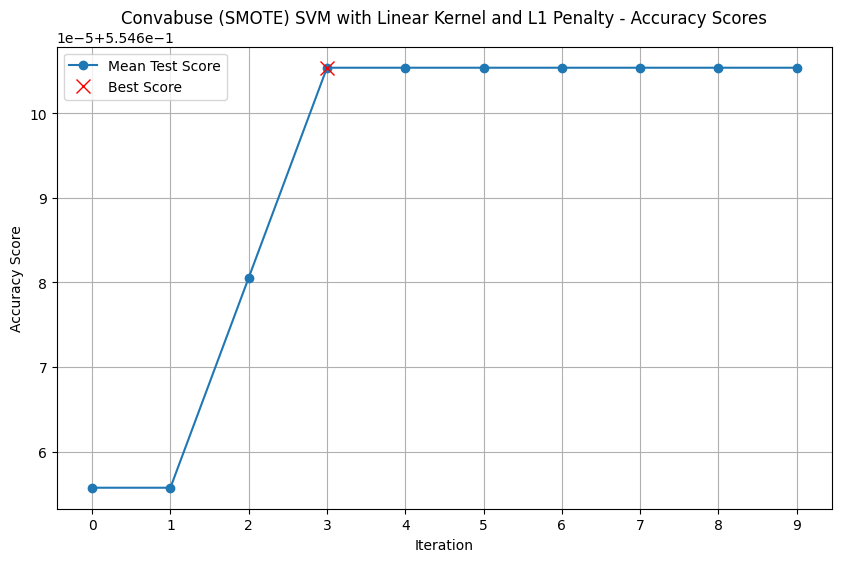

In [30]:
# Plot all accuracy scores for the SVM model with linear kernel and L1 penalty for each iteration
plt.figure(figsize=(10, 6))
plt.plot(convabuse_svm_linear_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
convabuse_linear_best_score_index = np.argmax(convabuse_svm_linear_grid_search.cv_results_['mean_test_score'])
plt.plot(convabuse_linear_best_score_index, convabuse_svm_linear_grid_search.cv_results_['mean_test_score'][convabuse_linear_best_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Convabuse ({balance}) SVM with Linear Kernel and L1 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.xticks(range(len(convabuse_svm_linear_grid_search.cv_results_['mean_test_score'])))
plt.grid()
plt.legend()
plt.show()

In [31]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(convabuse_svm_linear_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(convabuse_svm_linear_grid_search.best_score_)

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.4), 'loss': 'squared_hinge', 'max_iter': 16, 'tol': 0.0001}
Best score for SVM with linear kernel and L1 penalty:
0.5547053990438287


In [32]:
# Train the SVM model with the best parameters
convabuse_svm_model_linear = svm.LinearSVC(**convabuse_svm_linear_grid_search.best_params_, random_state=42)
convabuse_svm_model_linear.fit(convabuse_X_train, convabuse_y_train)

LinearSVC(C=np.float64(0.4), max_iter=16, random_state=42)

In [33]:
# Print the classification report for the convabuse_svm_model_linear model
convabuse_y_pred_linear = convabuse_svm_model_linear.predict(convabuse_X_test)
print("Classification report for SVM with linear kernel and L1 penalty:")
print(classification_report(convabuse_y_test, convabuse_y_pred_linear))
print(f"F1 Score: {f1_score(convabuse_y_test, convabuse_y_pred_linear, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(convabuse_y_test, convabuse_y_pred_linear):.4f}")

Classification report for SVM with linear kernel and L1 penalty:
              precision    recall  f1-score   support

           0       0.69      0.39      0.50      2013
           1       0.57      0.82      0.67      2012
           2       0.68      0.48      0.56      2013
           3       0.47      0.17      0.25      2013
           4       0.45      0.87      0.60      2012

    accuracy                           0.55     10063
   macro avg       0.57      0.55      0.52     10063
weighted avg       0.57      0.55      0.52     10063

F1 Score: 0.5165
Accuracy: 0.5470


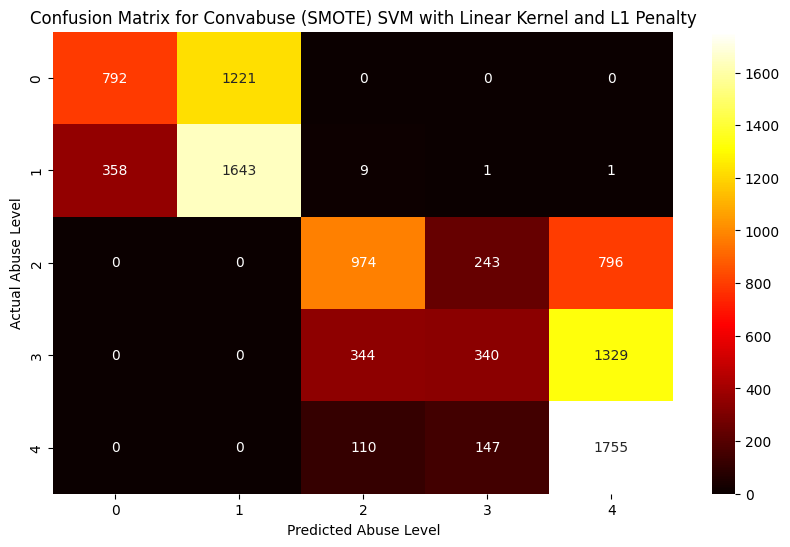

In [34]:
# Plot a heatmap of the actual vs predicted abuse levels for the convabuse_svm_model_linear model
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(convabuse_y_test, convabuse_y_pred_linear, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Convabuse ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Predicted Abuse Level')
plt.ylabel('Actual Abuse Level')
plt.show()

,feature,importance_mean,importance_std
5,explicit,0.117907,0.002468
6,implicit,0.101252,0.001247
4,system,0.097744,0.002489
1,bot,0.046169,0.002755
0,annotator_id,0.032128,0.001983
7,target_groups,0.005346,0.000844
3,individual,0.000000,0.000000
2,generalised,0.000000,0.000000


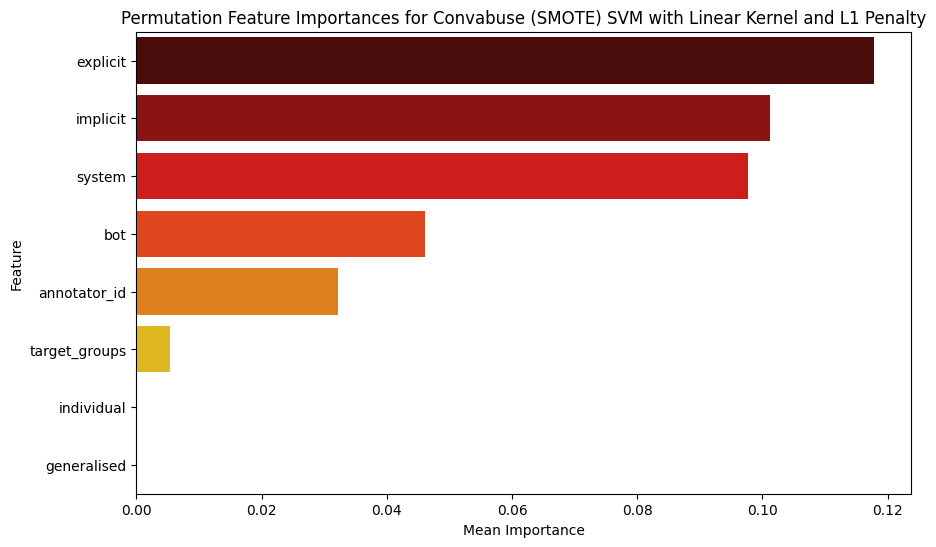

In [35]:
from sklearn.inspection import permutation_importance

# Determine the feature importances
perm_importance = permutation_importance(convabuse_svm_model_linear, convabuse_X_test, convabuse_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
convabuse_svm_model_linear_perm_importances = pd.DataFrame({
    'feature': convabuse_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(convabuse_svm_model_linear_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
convabuse_svm_model_linear_perm_importances_dict = convabuse_svm_model_linear_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=convabuse_svm_model_linear_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Convabuse ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [36]:
svm_classification_results_list.append(("Convabuse", "Linear", "L1", accuracy_score(convabuse_y_test, convabuse_y_pred_linear), f1_score(convabuse_y_test, convabuse_y_pred_linear, average='weighted'), convabuse_svm_model_linear_perm_importances_dict))

In [37]:
convabuse_svm_rbf_pipeline = Pipeline([
    ("kernel", RBFSampler()),
    ("clf", SGDClassifier(loss="hinge", random_state=42, penalty="l2", tol=1e-4))
])

In [38]:
# Use grid search to find the best hyperparameters for the SVM model
convabuse_svm_rbf_param_grid = {
    'kernel__gamma': np.linspace(0.1, 1, 10), # Kernel coefficient,
    'kernel__n_components': range(2, convabuse_X_train.shape[1] + 1), # Number of components for the RBF kernel
    'clf__alpha': [1e-4], # Regularization parameter
    'clf__max_iter': [convabuse_max_iter], # range(330, 350), # Maximum number of iterations
    'clf__tol': [1e-4], # Tolerance for stopping criteria
    'clf__early_stopping': [True] # Whether to use early stopping
}

In [39]:
# Perform a grid search using the RBFSampler
convabuse_svm_rbf_grid_search = GridSearchCV(
    estimator=convabuse_svm_rbf_pipeline,
    param_grid=
    convabuse_svm_rbf_param_grid,
    cv=convabuse_kfold,
    scoring='accuracy',
    n_jobs=2,
    verbose=True
)

In [40]:
# Fit the grid search to the training data
convabuse_svm_rbf_grid_search.fit(convabuse_X_train, convabuse_y_train)

Fitting 5 folds for each of 70 candidates, totalling 350 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('kernel', RBFSampler()),
                                       ('clf',
                                        SGDClassifier(random_state=42,
                                                      tol=0.0001))]),
             n_jobs=2,
             param_grid={'clf__alpha': [0.0001], 'clf__early_stopping': [True],
                         'clf__max_iter': [16], 'clf__tol': [0.0001],
                         'kernel__gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'kernel__n_components': range(2, 9)},
             scoring='accuracy', verbose=True)

In [41]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with RBF kernel:")
pprint(convabuse_svm_rbf_grid_search.best_params_)
print("Best score for SVM with RBF kernel:")
print(convabuse_svm_rbf_grid_search.best_score_)

Best parameters for SVM with RBF kernel:
{'clf__alpha': 0.0001,
 'clf__early_stopping': True,
 'clf__max_iter': 16,
 'clf__tol': 0.0001,
 'kernel__gamma': np.float64(0.1),
 'kernel__n_components': 8}
Best score for SVM with RBF kernel:
0.5497870948479838


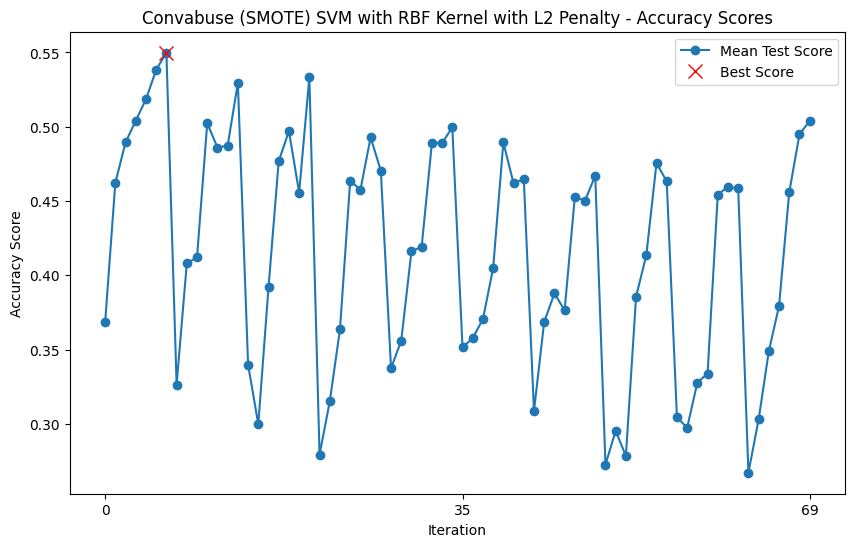

In [42]:
# Plot all accuracy scores for the SVM model with RBF kernel for each iteration
plt.figure(figsize=(10, 6))
plt.plot(convabuse_svm_rbf_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
best_convabuse_svm_rbf_score_index = np.argmax(convabuse_svm_rbf_grid_search.cv_results_['mean_test_score'])
plt.plot(best_convabuse_svm_rbf_score_index, convabuse_svm_rbf_grid_search.cv_results_['mean_test_score'][best_convabuse_svm_rbf_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Convabuse ({balance}) SVM with RBF Kernel with L2 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')

# Only plot x-axis ticks of 0, the median, and the last iteration
plt.xticks([0, len(convabuse_svm_rbf_grid_search.cv_results_['mean_test_score']) // 2, len(convabuse_svm_rbf_grid_search.cv_results_['mean_test_score']) - 1])

plt.legend()
plt.show()

In [43]:
# Train the SVM model with the best parameters
convabuse_svm_model_rbf = convabuse_svm_rbf_grid_search.best_estimator_
convabuse_svm_model_rbf.fit(convabuse_X_train, convabuse_y_train)

Pipeline(steps=[('kernel', RBFSampler(gamma=np.float64(0.1), n_components=8)),
                ('clf',
                 SGDClassifier(early_stopping=True, max_iter=16,
                               random_state=42, tol=0.0001))])

In [44]:
# Print the classification report for the convabuse_svm_model_rbf model
convabuse_y_pred_rbf = convabuse_svm_model_rbf.predict(convabuse_X_test)
print("Classification report for SVM with RBF kernel:")
print(classification_report(convabuse_y_test, convabuse_y_pred_rbf))
print(f"F1 Score: {f1_score(convabuse_y_test, convabuse_y_pred_rbf, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(convabuse_y_test, convabuse_y_pred_rbf):.4f}")

Classification report for SVM with RBF kernel:
              precision    recall  f1-score   support

           0       0.69      0.39      0.50      2013
           1       0.57      0.82      0.67      2012
           2       0.65      0.46      0.54      2013
           3       0.00      0.00      0.00      2013
           4       0.40      0.93      0.56      2012

    accuracy                           0.52     10063
   macro avg       0.46      0.52      0.45     10063
weighted avg       0.46      0.52      0.45     10063

F1 Score: 0.4544
Accuracy: 0.5185


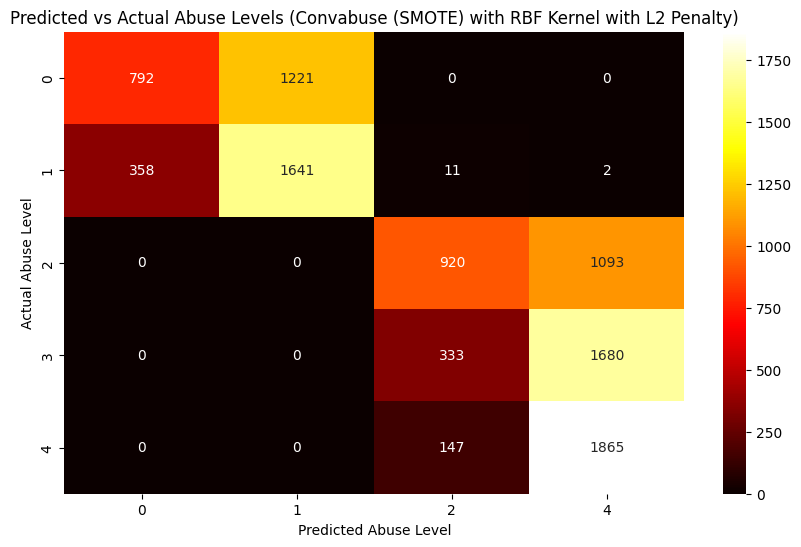

In [45]:
# Plot a heatmap of the predicted vs actual abuse levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(convabuse_y_test, convabuse_y_pred_rbf), annot=True, fmt='d', cmap='hot')
plt.title(f'Predicted vs Actual Abuse Levels (Convabuse ({balance}) with RBF Kernel with L2 Penalty)')
plt.xlabel('Predicted Abuse Level')
plt.ylabel('Actual Abuse Level')
plt.show()

,feature,importance_mean,importance_std
5,explicit,0.181427,0.002520
6,implicit,0.107831,0.001366
1,bot,0.045911,0.002670
4,system,0.038865,0.002639
7,target_groups,0.029246,0.001727
0,annotator_id,0.005972,0.001326
3,individual,0.000000,0.000000
2,generalised,0.000000,0.000000


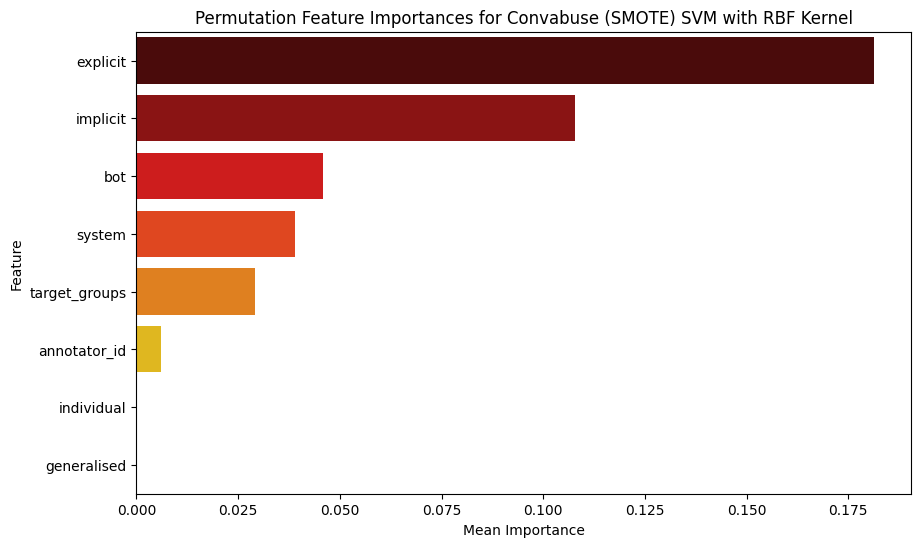

In [46]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(convabuse_svm_model_rbf, convabuse_X_test, convabuse_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
convabuse_svm_rbf_perm_importance = pd.DataFrame({
    'feature': convabuse_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(convabuse_svm_rbf_perm_importance)

# Condense into a dictionary with each feature key and importance mean value
convabuse_svm_rbf_perm_importances_dict = convabuse_svm_rbf_perm_importance.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=convabuse_svm_rbf_perm_importance, palette='hot')
plt.title(f'Permutation Feature Importances for Convabuse ({balance}) SVM with RBF Kernel')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [47]:
svm_classification_results_list.append(("Convabuse", "RBF", "L2", accuracy_score(convabuse_y_test, convabuse_y_pred_rbf), f1_score(convabuse_y_test, convabuse_y_pred_rbf, average='weighted'), convabuse_svm_rbf_perm_importances_dict))

In [48]:
convabuse_custom_param_grid = {
    "C": np.linspace(0.1, 1, 10),
    "kernel": ["linear"],
    "max_iter": range(1, convabuse_max_iter), # range(2960, 3000),
    "class_weight": ["balanced"]
}

In [49]:
# Train and evaluate the SVM model on the US Accidents Upsampled dataset
convabuse_custom_svm_grid_search, convabuse_custom_svm_model = svm_grid_search(convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test, convabuse_custom_param_grid, convabuse_kfold, "convabuse_custom_svm_model")

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Parameters tested for convabuse_custom_svm_model:
[{'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 1},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 2},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 3},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 4},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 5},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 6},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 7},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 8},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 9},
 {'C': np.float64(0.1),
  'class_weight':

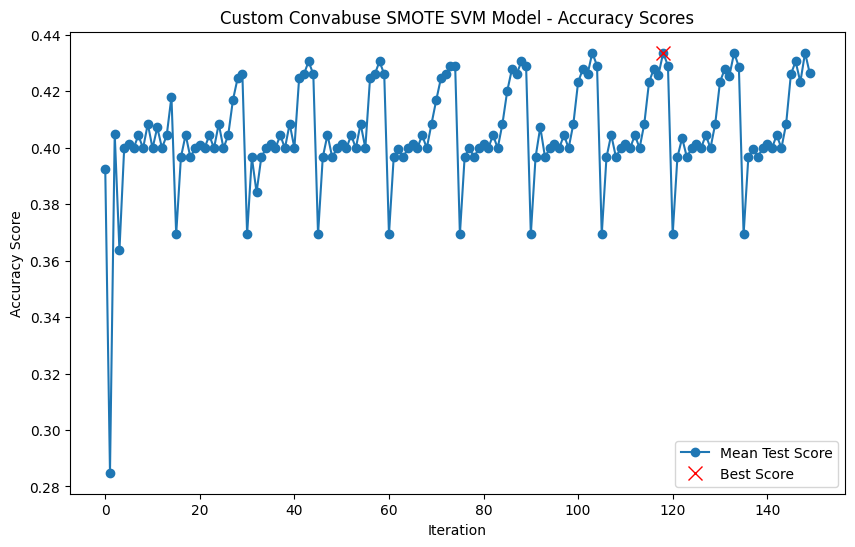

In [50]:
# Plot all accuracy scores for the custom SVM model
plt.figure(figsize=(10, 6))
plt.plot(convabuse_custom_svm_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the maximum accuracy score
best_convabuse_custom_svm_score_index = np.argmax(convabuse_custom_svm_grid_search.cv_results_['mean_test_score'])
plt.plot(best_convabuse_custom_svm_score_index, convabuse_custom_svm_grid_search.cv_results_['mean_test_score'][best_convabuse_custom_svm_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Custom Convabuse {balance} SVM Model - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [51]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(convabuse_custom_svm_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(convabuse_custom_svm_grid_search.best_score_)

# Get the best kernel
best_convabuse_custom_kernel = convabuse_custom_svm_grid_search.best_params_['kernel']

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.8),
 'class_weight': 'balanced',
 'kernel': 'linear',
 'max_iter': 14}
Best score for SVM with linear kernel and L1 penalty:
0.4336441582427552


In [52]:
# Train the SVM model with the best parameters
convabuse_custom_svm_best_model = convabuse_custom_svm_grid_search.best_estimator_
convabuse_custom_svm_best_model.fit(convabuse_X_train, convabuse_y_train)

SVC(C=np.float64(0.8), class_weight='balanced', kernel='linear', max_iter=14)

In [53]:
# Use the model to make predictions on the test set
convabuse_custom_y_pred = convabuse_custom_svm_model.predict(convabuse_X_test)

# Print the classification report
print("Classification report for Convabuse dataset with L1 regularization:")
print(classification_report(convabuse_y_test, convabuse_custom_y_pred))

Classification report for Convabuse dataset with L1 regularization:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2013
           1       0.50      0.99      0.66      2012
           2       0.93      0.06      0.12      2013
           3       0.19      0.08      0.11      2013
           4       0.40      1.00      0.57      2012

    accuracy                           0.43     10063
   macro avg       0.40      0.43      0.29     10063
weighted avg       0.40      0.43      0.29     10063



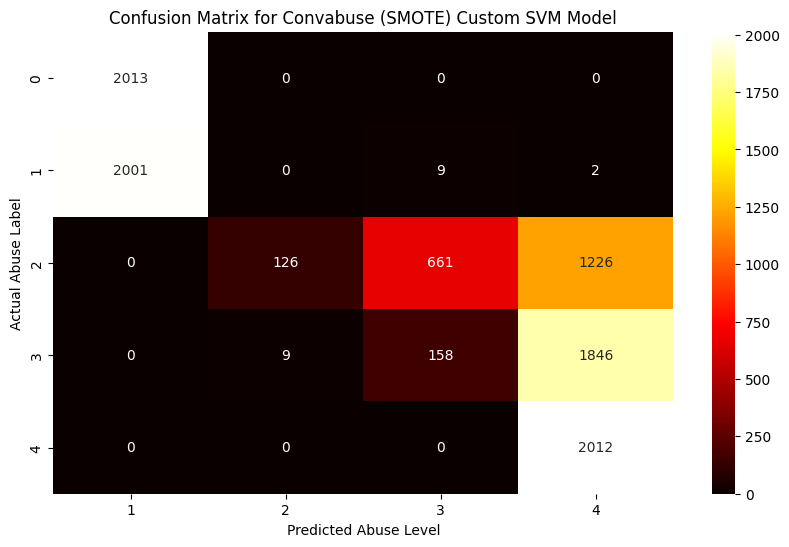

In [54]:
# Plot a heatmap of the predicted vs actual abuse levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(convabuse_y_test, convabuse_custom_y_pred, rownames=['Actual Abuse Label'], colnames=['Predicted Abuse Level']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Convabuse ({balance}) Custom SVM Model')
plt.show()

,feature,importance_mean,importance_std
5,explicit,0.098251,0.001658
4,system,0.090182,0.001632
6,implicit,0.027606,0.001414
1,bot,0.000000,0.000000
2,generalised,0.000000,0.000000
3,individual,0.000000,0.000000
7,target_groups,0.000000,0.000000
0,annotator_id,-0.015423,0.001341


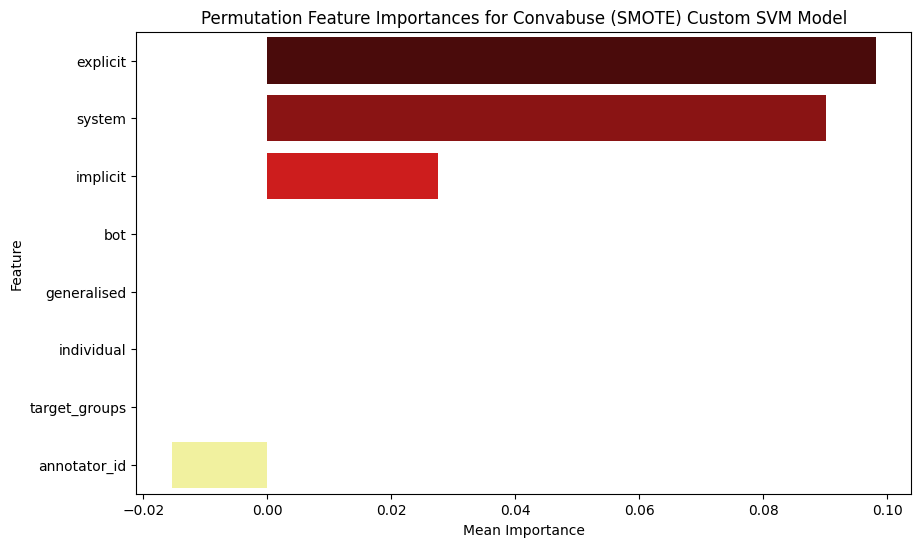

In [55]:
from sklearn.inspection import permutation_importance

# Determine the feature importances using permutation importance
perm_importance = permutation_importance(convabuse_custom_svm_best_model, convabuse_X_test, convabuse_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
convabuse_custom_svm_model_perm_importances = pd.DataFrame({
    'feature': convabuse_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(convabuse_custom_svm_model_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
convabuse_custom_svm_model_perm_importances_dict = convabuse_custom_svm_model_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=convabuse_custom_svm_model_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Convabuse ({balance}) Custom SVM Model')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [56]:
# Get the custom model's accuracy and f1-score
convabuse_custom_accuracy = accuracy_score(convabuse_y_test, convabuse_custom_y_pred)
convabuse_custom_f1_score = f1_score(convabuse_y_test, convabuse_custom_y_pred, average='weighted')
print(f"Custom SVM Model Accuracy: {convabuse_custom_accuracy}")
print(f"Custom SVM Model F1-Score: {convabuse_custom_f1_score}")

Custom SVM Model Accuracy: 0.42700983802047104
Custom SVM Model F1-Score: 0.2918535391341153


In [57]:
svm_classification_results_list.append(("Convabuse", best_convabuse_custom_kernel, "L1", convabuse_custom_accuracy, convabuse_custom_f1_score, convabuse_custom_svm_model_perm_importances_dict))

In [58]:
svm_classification_results_list

[('Convabuse',
  'Linear',
  'L1',
  0.546954188611746,
  0.5165317953569895,
  {'explicit': 0.11790718473616224,
   'implicit': 0.10125211169631325,
   'system': 0.09774421146775321,
   'bot': 0.0461691344529465,
   'annotator_id': 0.032127596144291025,
   'target_groups': 0.005346318195369226,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'RBF',
  'L2',
  0.5185332405843188,
  0.4544228996956412,
  {'explicit': 0.1814270098380205,
   'implicit': 0.10783066679916531,
   'bot': 0.045910762198151676,
   'system': 0.038865149557785986,
   'target_groups': 0.029245751763887544,
   'annotator_id': 0.005972374043525808,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'linear',
  'L1',
  0.42700983802047104,
  0.2918535391341153,
  {'explicit': 0.09825101858292758,
   'system': 0.09018185431779788,
   'implicit': 0.027606081685382106,
   'bot': 0.0,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': 0.0,
   'annotator_id': -0.01542283613236609}

## Dynamicaly Generated Hate Speech Support Vector Machines

In [59]:
# Use grid search to find the best hyperparameters for the Linear SVC model
dghs_svm_linear_param_grid = {
    'C': np.linspace(0.1, 1, 10), # Regularization parameter
    'loss': ['squared_hinge'], # Loss function
    'max_iter': range(1, dghs_max_iter), # range(1, 8), # Maximum number of iterations
    'tol': [1e-4] # Tolerance for stopping criteria
}

In [60]:
dghs_svm_linear_grid_search = GridSearchCV(svm.LinearSVC(), dghs_svm_linear_param_grid, cv=dghs_kfold, scoring='accuracy')
dghs_svm_linear_grid_search.fit(dghs_X_train, dghs_y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(),
             param_grid={'C': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'loss': ['squared_hinge'], 'max_iter': range(1, 16),
                         'tol': [0.0001]},
             scoring='accuracy')

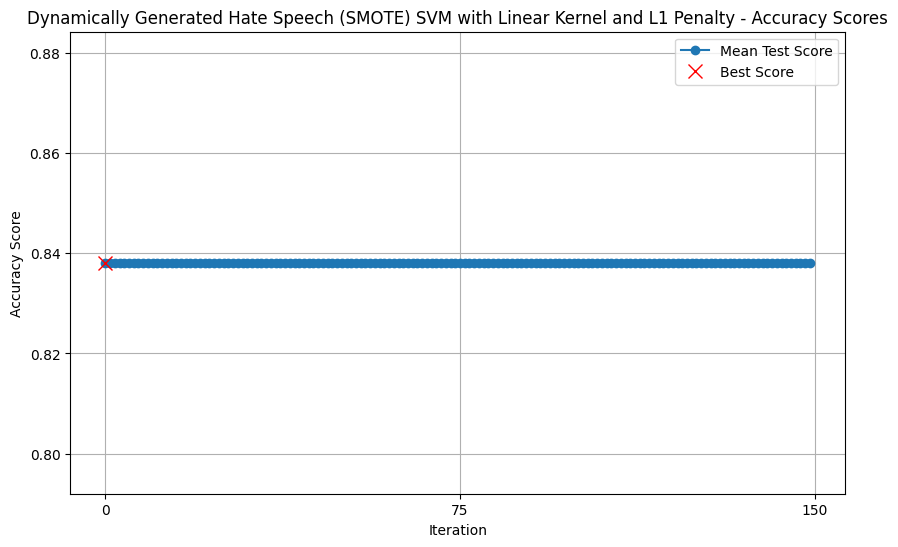

In [61]:
# Plot all accuracy scores for the SVM model with linear kernel and L1 penalty for each iteration
plt.figure(figsize=(10, 6))
plt.plot(dghs_svm_linear_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
dghs_linear_best_score_index = np.argmax(dghs_svm_linear_grid_search.cv_results_['mean_test_score'])
plt.plot(dghs_linear_best_score_index, dghs_svm_linear_grid_search.cv_results_['mean_test_score'][dghs_linear_best_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Dynamically Generated Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.xticks([0, len(dghs_svm_linear_grid_search.cv_results_['mean_test_score']) / 2, len(dghs_svm_linear_grid_search.cv_results_['mean_test_score'])])
plt.grid()
plt.legend()
plt.show()

In [62]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with linear kernel and L1 penalty (from pickled model):")
pprint(dghs_svm_linear_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty (from pickled model):")
print(dghs_svm_linear_grid_search.best_score_)

Best parameters for SVM with linear kernel and L1 penalty (from pickled model):
{'C': np.float64(0.1), 'loss': 'squared_hinge', 'max_iter': 1, 'tol': 0.0001}
Best score for SVM with linear kernel and L1 penalty (from pickled model):
0.8381131249181657


In [63]:
# Train the SVM model with the best parameters
dghs_svm_model_linear = svm.LinearSVC(**dghs_svm_linear_grid_search.best_params_, random_state=42)
dghs_svm_model_linear.fit(dghs_X_train, dghs_y_train)

LinearSVC(C=np.float64(0.1), max_iter=1, random_state=42)

In [64]:
# Print the classification report for the dghs_svm_model_linear model
dghs_y_pred_linear = dghs_svm_model_linear.predict(dghs_X_test)
print("Classification report for SVM with linear kernel and L1 penalty:")
print(classification_report(dghs_y_test, dghs_y_pred_linear))
print(f"F1 Score: {f1_score(dghs_y_test, dghs_y_pred_linear, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(dghs_y_test, dghs_y_pred_linear):.4f}")

Classification report for SVM with linear kernel and L1 penalty:
              precision    recall  f1-score   support

         0.0       0.76      1.00      0.86      4394
         1.0       1.00      0.68      0.81      4394

    accuracy                           0.84      8788
   macro avg       0.88      0.84      0.83      8788
weighted avg       0.88      0.84      0.83      8788

F1 Score: 0.8341
Accuracy: 0.8384


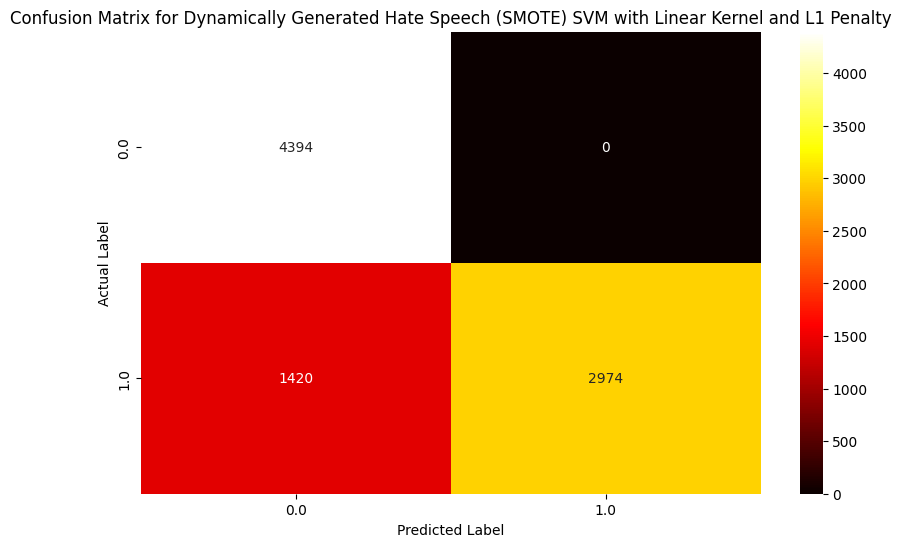

In [65]:
# Plot a heatmap of the actual vs predicted label for the us_accidents_svm_model_linear model
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(dghs_y_test, dghs_y_pred_linear, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Dynamically Generated Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

,feature,importance_mean,importance_std
0,type,0.339622,0.003902
1,annotator,0.000000,0.000000
2,target_groups,0.000000,0.000000
3,original,0.000000,0.000000


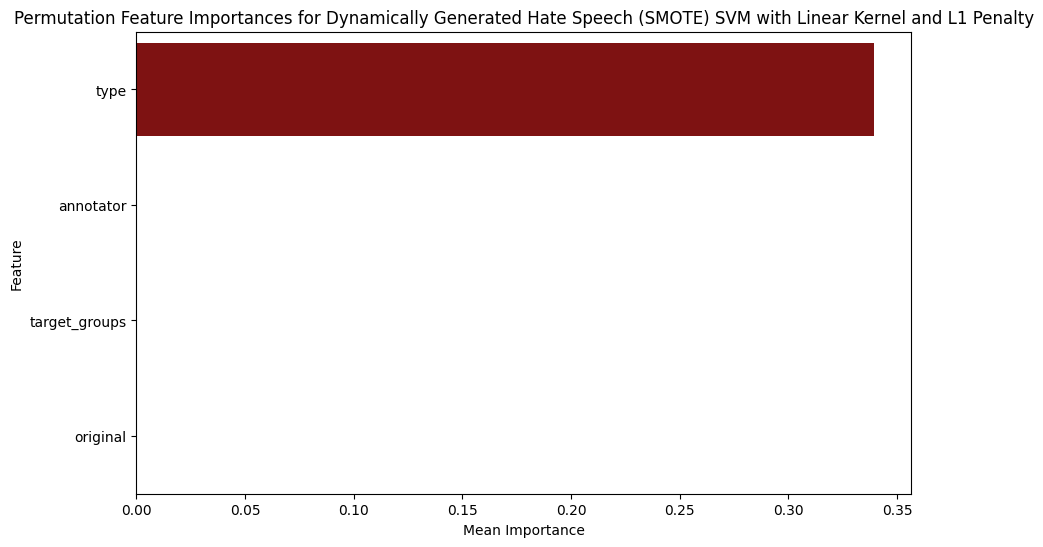

In [66]:
from sklearn.inspection import permutation_importance

# Determine the feature importances
perm_importance = permutation_importance(dghs_svm_model_linear, dghs_X_test, dghs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
dghs_svm_model_linear_perm_importances = pd.DataFrame({
    'feature': dghs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)
display(dghs_svm_model_linear_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
dghs_svm_model_linear_perm_importances_dict = dghs_svm_model_linear_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=dghs_svm_model_linear_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Dynamically Generated Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [67]:
svm_classification_results_list.append(("Dynamically Generated Hate Speech", "Linear", "L1", accuracy_score(dghs_y_test, dghs_y_pred_linear), f1_score(dghs_y_test, dghs_y_pred_linear, average='weighted'), dghs_svm_model_linear_perm_importances_dict))

In [68]:
dghs_svm_rbf_pipeline = Pipeline([
    ("kernel", RBFSampler()),
    ("clf", SGDClassifier(loss="hinge", random_state=42, penalty="l2", tol=1e-4))
])

In [69]:
# Use grid search to find the best hyperparameters for the SVM model
dghs_svm_rbf_param_grid = {
    'kernel__gamma': np.linspace(0.1, 1, 10), # Kernel coefficient,
    'kernel__n_components': range(2, dghs_X_train.shape[1] + 1), # Number of components for the RBF kernel
    'clf__alpha': [1e-4], # Regularization parameter
    'clf__max_iter': range(1, dghs_max_iter), # range(300, 350), # Maximum number of iterations
    'clf__tol': [1e-4], # Tolerance for stopping criteria
    'clf__early_stopping': [True] # Whether to use early stopping
}

In [70]:
# Perform a grid search using the RBFSampler
dghs_svm_rbf_grid_search = GridSearchCV(
    estimator=dghs_svm_rbf_pipeline,
    param_grid=
    dghs_svm_rbf_param_grid,
    cv=dghs_kfold,
    scoring='accuracy',
    n_jobs=2,
    verbose=True
)

In [71]:
# Fit the grid search to the training data
dghs_svm_rbf_grid_search.fit(dghs_X_train, dghs_y_train)

Fitting 5 folds for each of 450 candidates, totalling 2250 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('kernel', RBFSampler()),
                                       ('clf',
                                        SGDClassifier(random_state=42,
                                                      tol=0.0001))]),
             n_jobs=2,
             param_grid={'clf__alpha': [0.0001], 'clf__early_stopping': [True],
                         'clf__max_iter': range(1, 16), 'clf__tol': [0.0001],
                         'kernel__gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'kernel__n_components': range(2, 5)},
             scoring='accuracy', verbose=True)

In [72]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with RBF kernel (from pickled model):")
pprint(dghs_svm_rbf_grid_search.best_params_)
print("Best score for SVM with RBF kernel (from pickled model):")
print(dghs_svm_rbf_grid_search.best_score_)

Best parameters for SVM with RBF kernel (from pickled model):
{'clf__alpha': 0.0001,
 'clf__early_stopping': True,
 'clf__max_iter': 14,
 'clf__tol': 0.0001,
 'kernel__gamma': np.float64(0.2),
 'kernel__n_components': 4}
Best score for SVM with RBF kernel (from pickled model):
0.8344141634727255


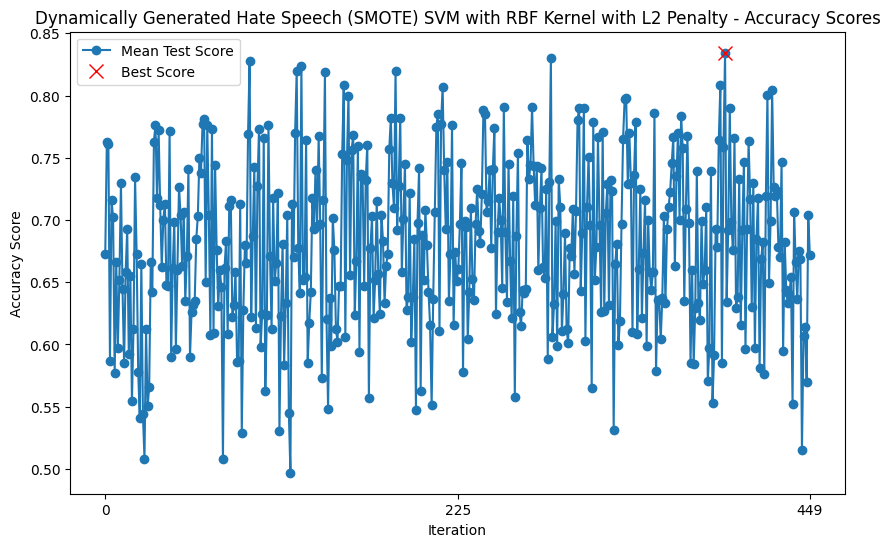

In [73]:
# Plot all accuracy scores for the SVM model with RBF kernel for each iteration
plt.figure(figsize=(10, 6))
plt.plot(dghs_svm_rbf_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
best_dghs_svm_rbf_score_index = np.argmax(dghs_svm_rbf_grid_search.cv_results_['mean_test_score'])
plt.plot(best_dghs_svm_rbf_score_index, dghs_svm_rbf_grid_search.cv_results_['mean_test_score'][best_dghs_svm_rbf_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Dynamically Generated Hate Speech ({balance}) SVM with RBF Kernel with L2 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')

# Only plot x-axis ticks of 0, the median, and the last iteration
plt.xticks([0, len(dghs_svm_rbf_grid_search.cv_results_['mean_test_score']) // 2, len(dghs_svm_rbf_grid_search.cv_results_['mean_test_score']) - 1])

plt.legend()
plt.show()

In [74]:
# Train the SVM model with the best parameters
dghs_svm_model_rbf = dghs_svm_rbf_grid_search.best_estimator_
dghs_svm_model_rbf.fit(dghs_X_train, dghs_y_train)

Pipeline(steps=[('kernel', RBFSampler(gamma=np.float64(0.2), n_components=4)),
                ('clf',
                 SGDClassifier(early_stopping=True, max_iter=14,
                               random_state=42, tol=0.0001))])

In [75]:
# Print the classification report for the dghs_svm_model_rbf model
dghs_y_pred_rbf = dghs_svm_model_rbf.predict(dghs_X_test)
print(f"Classification report for SVM with RBF kernel:")
print(classification_report(dghs_y_test, dghs_y_pred_rbf))
print(f"F1 Score: {f1_score(dghs_y_test, dghs_y_pred_rbf, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(dghs_y_test, dghs_y_pred_rbf):.4f}")

Classification report for SVM with RBF kernel:
              precision    recall  f1-score   support

         0.0       0.74      1.00      0.85      4394
         1.0       1.00      0.64      0.78      4394

    accuracy                           0.82      8788
   macro avg       0.87      0.82      0.81      8788
weighted avg       0.87      0.82      0.81      8788

F1 Score: 0.8143
Accuracy: 0.8203


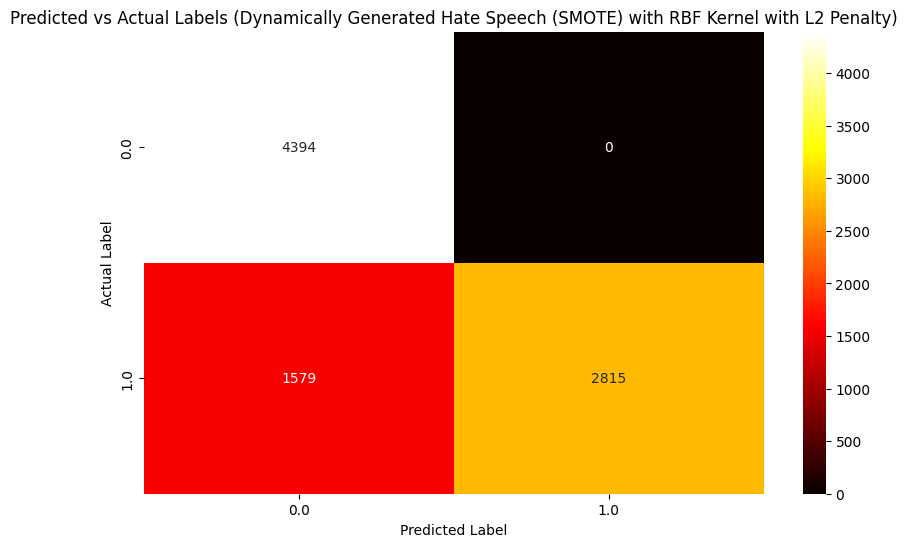

In [76]:
# Plot a heatmap of the predicted vs actual labels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(dghs_y_test, dghs_y_pred_rbf), annot=True, fmt='d', cmap='hot')
plt.title(f'Predicted vs Actual Labels (Dynamically Generated Hate Speech ({balance}) with RBF Kernel with L2 Penalty)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

,feature,importance_mean,importance_std
0,type,0.241193,0.003931
2,target_groups,0.061083,0.002793
3,original,0.002469,0.001100
1,annotator,-0.000011,0.001330


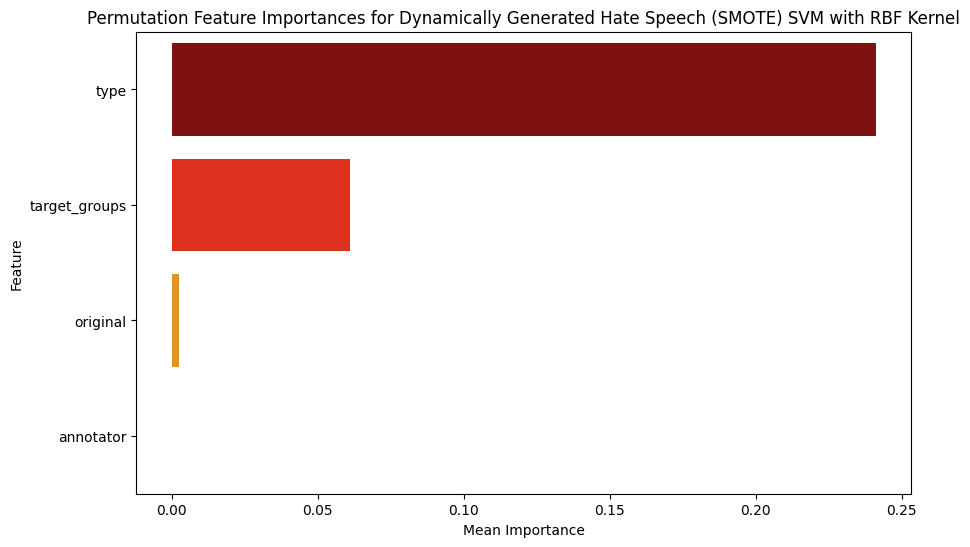

In [77]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(dghs_svm_model_rbf, dghs_X_test, dghs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
dghs_svm_rbf_perm_importance = pd.DataFrame({
    'feature': dghs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(dghs_svm_rbf_perm_importance)

# Condense into a dictionary with each feature key and importance mean value
dghs_svm_rbf_perm_importances_dict = dghs_svm_rbf_perm_importance.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=dghs_svm_rbf_perm_importance, palette='hot')
plt.title(f'Permutation Feature Importances for Dynamically Generated Hate Speech ({balance}) SVM with RBF Kernel')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [78]:
svm_classification_results_list.append(("Dynamically Generated Hate Speech", "RBF", "L2", accuracy_score(dghs_y_test, dghs_y_pred_rbf), f1_score(dghs_y_test, dghs_y_pred_rbf, average='weighted'), dghs_svm_rbf_perm_importances_dict))

In [79]:
dghs_custom_param_grid = {
    "C": np.linspace(0.1, 1, 10),
    "kernel": ["linear", "poly", "rbf"],
    "max_iter": range(1, dghs_max_iter), # range(100, 1000, 100),
    "class_weight": [None]
}

In [80]:
# Train and evaluate the SVM model on the US Accidents Upsampled dataset
dghs_custom_svm_grid_search, dghs_custom_svm_model = svm_grid_search(dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test, dghs_custom_param_grid, dghs_kfold, "dghs_custom_svm_model")

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Parameters tested for dghs_custom_svm_model:
[{'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 1},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 2},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 3},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 4},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 5},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 6},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 7},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 8},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 9},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 10},
 {'C': np.

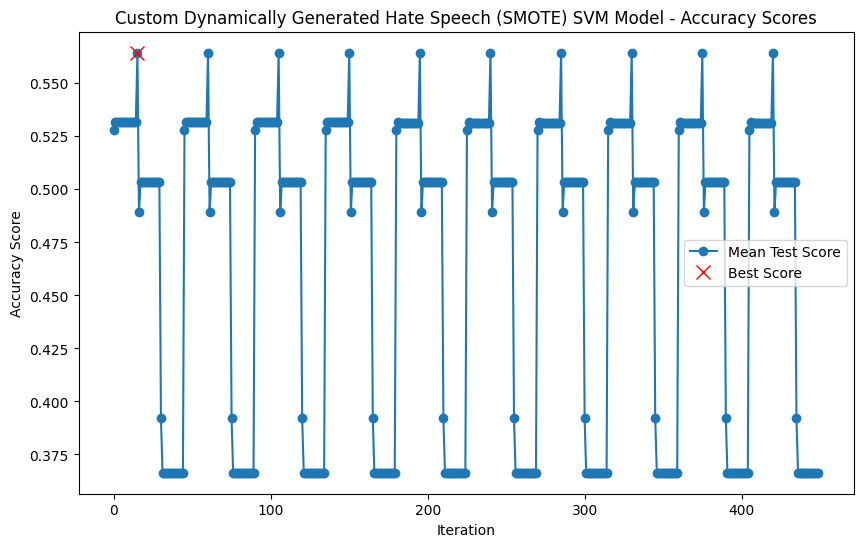

In [81]:
# Plot all accuracy scores for the custom SVM model
plt.figure(figsize=(10, 6))
plt.plot(dghs_custom_svm_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the maximum accuracy score
best_dghs_custom_svm_score_index = np.argmax(dghs_custom_svm_grid_search.cv_results_['mean_test_score'])
plt.plot(best_dghs_custom_svm_score_index, dghs_custom_svm_grid_search.cv_results_['mean_test_score'][best_dghs_custom_svm_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Custom Dynamically Generated Hate Speech ({balance}) SVM Model - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [82]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with linear kernel and L1 penalty (from pickled model):")
pprint(dghs_custom_svm_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty (from pickled model):")
print(dghs_custom_svm_grid_search.best_score_)

# Get the best kernel
best_dghs_custom_kernel = dghs_custom_svm_grid_search.best_params_['kernel']
print(f"Best kernel: {best_dghs_custom_kernel}")

Best parameters for SVM with linear kernel and L1 penalty (from pickled model):
{'C': np.float64(0.1), 'class_weight': None, 'kernel': 'poly', 'max_iter': 1}
Best score for SVM with linear kernel and L1 penalty (from pickled model):
0.56444255833433
Best kernel: poly


In [83]:
# Train the SVM model with the best parameters
dghs_custom_svm_best_model = dghs_custom_svm_grid_search.best_estimator_
dghs_custom_svm_best_model.fit(dghs_X_train, dghs_y_train)

SVC(C=np.float64(0.1), kernel='poly', max_iter=1)

In [84]:
# Use the model to make predictions on the test set
dghs_custom_y_pred = dghs_custom_svm_model.predict(dghs_X_test)

# Print the classification report
print("Classification report for US Accidents Upsampled dataset with L1 regularization:")
print(classification_report(dghs_y_test, dghs_custom_y_pred))

Classification report for US Accidents Upsampled dataset with L1 regularization:
              precision    recall  f1-score   support

         0.0       0.62      0.38      0.47      4394
         1.0       0.55      0.77      0.64      4394

    accuracy                           0.57      8788
   macro avg       0.59      0.57      0.56      8788
weighted avg       0.59      0.57      0.56      8788



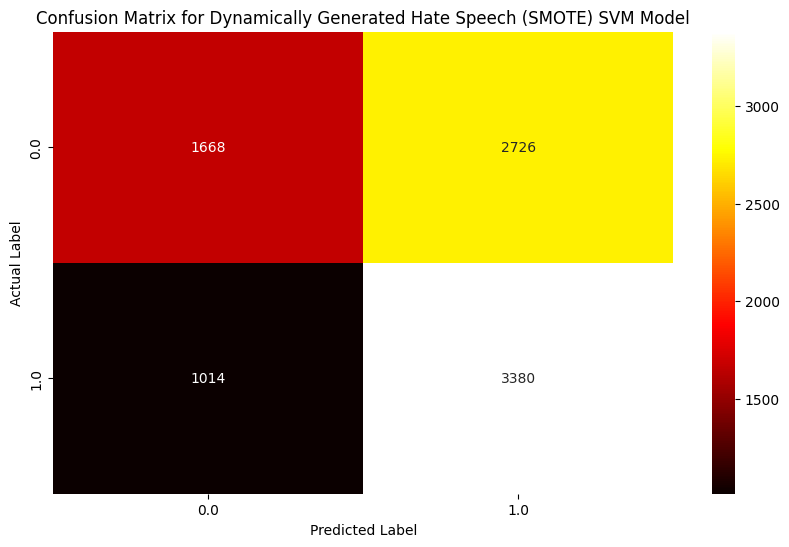

In [85]:
# Plot a heatmap of the predicted vs actual labels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(dghs_y_test, dghs_custom_y_pred, rownames=['Actual Label'], colnames=['Predicted Label']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Dynamically Generated Hate Speech ({balance}) SVM Model')
plt.show()

,feature,importance_mean,importance_std
3,original,0.037858,0.004261
0,type,0.022076,0.002928
1,annotator,-0.005416,0.000478
2,target_groups,-0.032021,0.001766


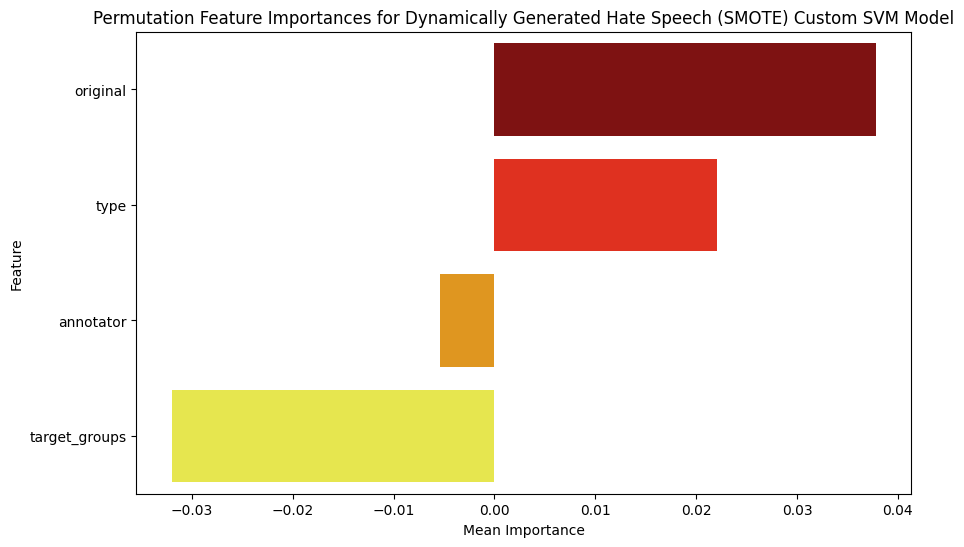

In [86]:
from sklearn.inspection import permutation_importance

# Determine the feature importances using permutation importance
perm_importance = permutation_importance(dghs_custom_svm_best_model, dghs_X_test, dghs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
dghs_custom_svm_model_perm_importances = pd.DataFrame({
    'feature': dghs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(dghs_custom_svm_model_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
dghs_custom_svm_model_perm_importances_dict = dghs_custom_svm_model_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=dghs_custom_svm_model_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Dynamically Generated Hate Speech ({balance}) Custom SVM Model')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [87]:
# Get the custom model's accuracy and f1-score
dghs_custom_accuracy = accuracy_score(dghs_y_test, dghs_custom_y_pred)
dghs_custom_f1_score = f1_score(dghs_y_test, dghs_custom_y_pred, average='weighted')
print(f"Custom SVM Model Accuracy: {dghs_custom_accuracy}")
print(f"Custom SVM Model F1-Score: {dghs_custom_f1_score}")

Custom SVM Model Accuracy: 0.5744196631770596
Custom SVM Model F1-Score: 0.5576311610002961


In [88]:
svm_classification_results_list.append(("Dynamically Generated Hate Speech", best_dghs_custom_kernel, "L1", dghs_custom_accuracy, dghs_custom_f1_score, dghs_custom_svm_model_perm_importances_dict))

In [89]:
svm_classification_results_list

[('Convabuse',
  'Linear',
  'L1',
  0.546954188611746,
  0.5165317953569895,
  {'explicit': 0.11790718473616224,
   'implicit': 0.10125211169631325,
   'system': 0.09774421146775321,
   'bot': 0.0461691344529465,
   'annotator_id': 0.032127596144291025,
   'target_groups': 0.005346318195369226,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'RBF',
  'L2',
  0.5185332405843188,
  0.4544228996956412,
  {'explicit': 0.1814270098380205,
   'implicit': 0.10783066679916531,
   'bot': 0.045910762198151676,
   'system': 0.038865149557785986,
   'target_groups': 0.029245751763887544,
   'annotator_id': 0.005972374043525808,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'linear',
  'L1',
  0.42700983802047104,
  0.2918535391341153,
  {'explicit': 0.09825101858292758,
   'system': 0.09018185431779788,
   'implicit': 0.027606081685382106,
   'bot': 0.0,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': 0.0,
   'annotator_id': -0.01542283613236609}

## Online Abusive Attacks Support Vector Machines

In [90]:
# Use grid search to find the best hyperparameters for the Linear SVC model
oaa_svm_linear_param_grid = {
    'C': np.linspace(0.1, 1, 10), # Regularization parameter
    'loss': ['squared_hinge'], # Loss function
    'max_iter': range(1, oaa_max_iter), # range(1, 8), # Maximum number of iterations
    'tol': [1e-4] # Tolerance for stopping criteria
}

In [91]:
oaa_svm_linear_grid_search = GridSearchCV(svm.LinearSVC(), oaa_svm_linear_param_grid, cv=oaa_kfold, scoring='accuracy')
oaa_svm_linear_grid_search.fit(oaa_X_train, oaa_y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(),
             param_grid={'C': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'loss': ['squared_hinge'], 'max_iter': range(1, 13),
                         'tol': [0.0001]},
             scoring='accuracy')

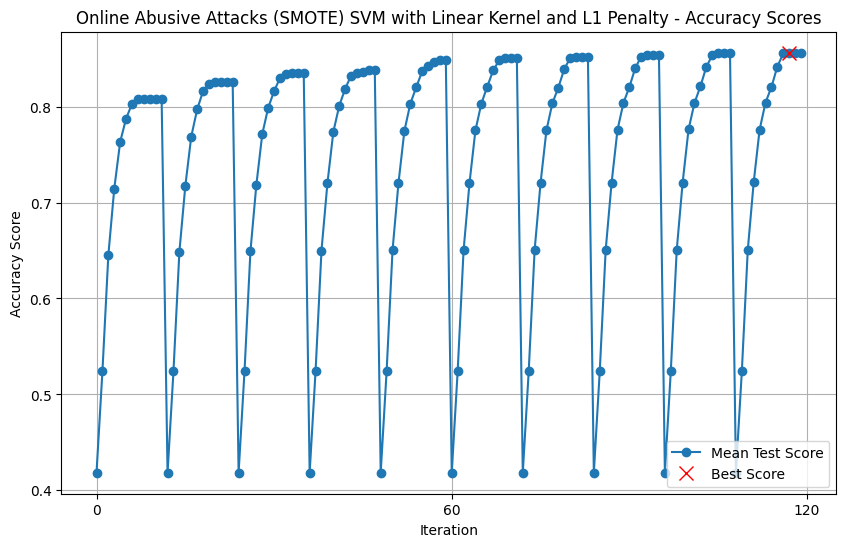

In [92]:
# Plot all accuracy scores for the SVM model with linear kernel and L1 penalty for each iteration
plt.figure(figsize=(10, 6))
plt.plot(oaa_svm_linear_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
oaa_linear_best_score_index = np.argmax(oaa_svm_linear_grid_search.cv_results_['mean_test_score'])
plt.plot(oaa_linear_best_score_index, oaa_svm_linear_grid_search.cv_results_['mean_test_score'][oaa_linear_best_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Online Abusive Attacks ({balance}) SVM with Linear Kernel and L1 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.xticks([0, len(oaa_svm_linear_grid_search.cv_results_['mean_test_score']) / 2, len(oaa_svm_linear_grid_search.cv_results_['mean_test_score'])])
plt.grid()
plt.legend()
plt.show()

In [93]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(oaa_svm_linear_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(oaa_svm_linear_grid_search.best_score_)

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(1.0), 'loss': 'squared_hinge', 'max_iter': 10, 'tol': 0.0001}
Best score for SVM with linear kernel and L1 penalty:
0.8561180975973508


In [94]:
# Train the SVM model with the best parameters
oaa_svm_model_linear = svm.LinearSVC(**oaa_svm_linear_grid_search.best_params_, random_state=42)
oaa_svm_model_linear.fit(oaa_X_train, oaa_y_train)

LinearSVC(C=np.float64(1.0), max_iter=10, random_state=42)

In [95]:
# Print the classification report for the oaa_svm_model_linear model
oaa_y_pred_linear = oaa_svm_model_linear.predict(oaa_X_test)
print("Classification report for SVM with linear kernel and L1 penalty:")
print(classification_report(oaa_y_test, oaa_y_pred_linear))
print(f"F1 Score: {f1_score(oaa_y_test, oaa_y_pred_linear, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(oaa_y_test, oaa_y_pred_linear):.4f}")

Classification report for SVM with linear kernel and L1 penalty:
              precision    recall  f1-score   support

           0       0.75      1.00      0.85       223
           1       0.92      0.66      0.77       222
           2       0.91      0.78      0.84       222
           3       0.85      0.90      0.87       223
           4       0.97      1.00      0.99       222

    accuracy                           0.87      1112
   macro avg       0.88      0.87      0.86      1112
weighted avg       0.88      0.87      0.86      1112

F1 Score: 0.8647
Accuracy: 0.8678


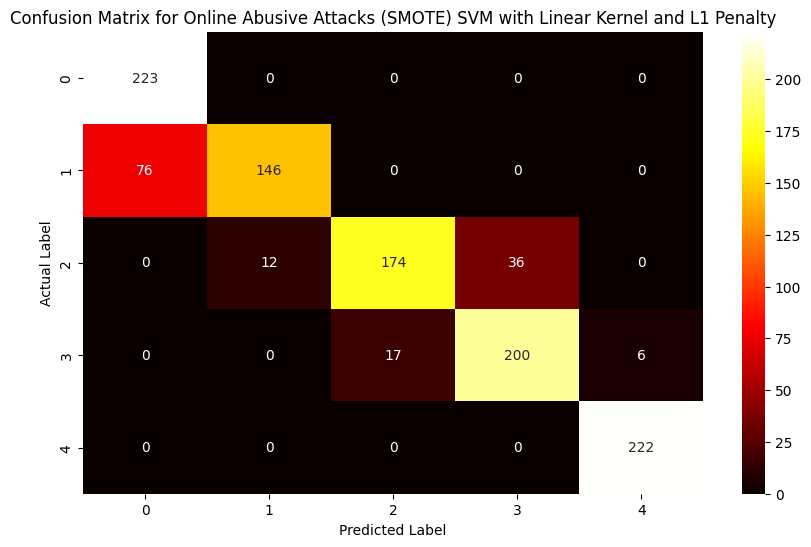

In [96]:
# Plot a heatmap of the actual vs predicted label for the us_accidents_svm_model_linear model
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(oaa_y_test, oaa_y_pred_linear, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Online Abusive Attacks ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

,feature,importance_mean,importance_std
0,Toxic parent tweets,0.611061,0.009704
1,Toxic replies,0.204406,0.005745


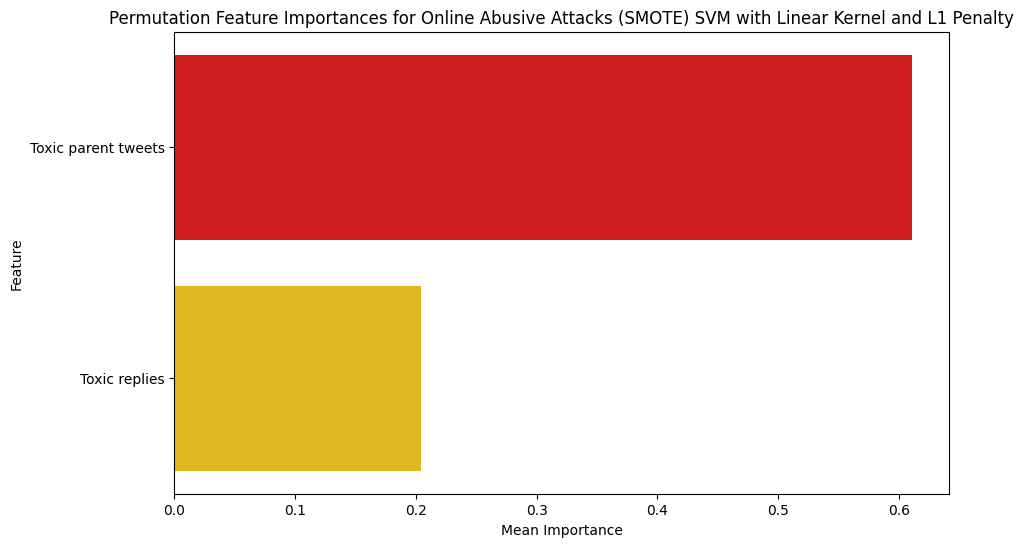

In [97]:
from sklearn.inspection import permutation_importance

# Determine the feature importances
perm_importance = permutation_importance(oaa_svm_model_linear, oaa_X_test, oaa_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
oaa_svm_model_linear_perm_importances = pd.DataFrame({
    'feature': oaa_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)
display(oaa_svm_model_linear_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
oaa_svm_model_linear_perm_importances_dict = oaa_svm_model_linear_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=oaa_svm_model_linear_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Online Abusive Attacks ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [98]:
svm_classification_results_list.append(("Online Abusive Attacks", "Linear", "L1", accuracy_score(dghs_y_test, dghs_y_pred_linear), f1_score(dghs_y_test, dghs_y_pred_linear, average='weighted'), dghs_svm_model_linear_perm_importances_dict))

In [99]:
oaa_svm_rbf_pipeline = Pipeline([
    ("kernel", RBFSampler()),
    ("clf", SGDClassifier(loss="hinge", random_state=42, penalty="l2", tol=1e-4))
])

In [100]:
# Use grid search to find the best hyperparameters for the SVM model
oaa_svm_rbf_param_grid = {
    'kernel__gamma': np.linspace(0.1, 1, 10), # Kernel coefficient,
    'kernel__n_components': range(2, oaa_X_train.shape[1] + 1), # Number of components for the RBF kernel
    'clf__alpha': [1e-4], # Regularization parameter
    'clf__max_iter': range(1, oaa_max_iter), # range(300, 350), # Maximum number of iterations
    'clf__tol': [1e-4], # Tolerance for stopping criteria
    'clf__early_stopping': [True] # Whether to use early stopping
}

In [101]:
# Perform a grid search using the RBFSampler
oaa_svm_rbf_grid_search = GridSearchCV(
    estimator=oaa_svm_rbf_pipeline,
    param_grid=
    oaa_svm_rbf_param_grid,
    cv=oaa_kfold,
    scoring='accuracy',
    n_jobs=2,
    verbose=True
)

In [102]:
# Fit the grid search to the training data
oaa_svm_rbf_grid_search.fit(oaa_X_train, oaa_y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('kernel', RBFSampler()),
                                       ('clf',
                                        SGDClassifier(random_state=42,
                                                      tol=0.0001))]),
             n_jobs=2,
             param_grid={'clf__alpha': [0.0001], 'clf__early_stopping': [True],
                         'clf__max_iter': range(1, 13), 'clf__tol': [0.0001],
                         'kernel__gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'kernel__n_components': range(2, 3)},
             scoring='accuracy', verbose=True)

In [103]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with RBF kernel (from pickled model):")
pprint(oaa_svm_rbf_grid_search.best_params_)
print("Best score for SVM with RBF kernel (from pickled model):")
print(oaa_svm_rbf_grid_search.best_score_)

Best parameters for SVM with RBF kernel (from pickled model):
{'clf__alpha': 0.0001,
 'clf__early_stopping': True,
 'clf__max_iter': 9,
 'clf__tol': 0.0001,
 'kernel__gamma': np.float64(0.2),
 'kernel__n_components': 2}
Best score for SVM with RBF kernel (from pickled model):
0.7068998116808431


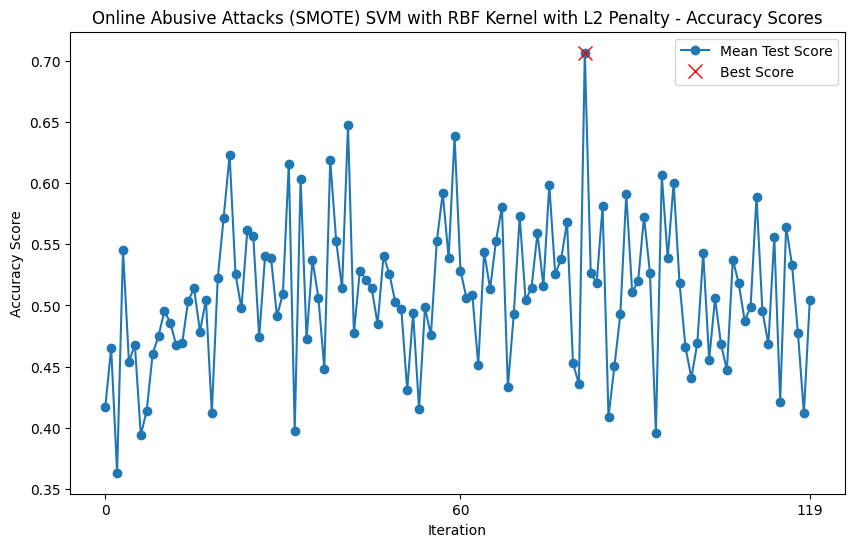

In [104]:
# Plot all accuracy scores for the SVM model with RBF kernel for each iteration
plt.figure(figsize=(10, 6))
plt.plot(oaa_svm_rbf_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
best_oaa_svm_rbf_score_index = np.argmax(oaa_svm_rbf_grid_search.cv_results_['mean_test_score'])
plt.plot(best_oaa_svm_rbf_score_index, oaa_svm_rbf_grid_search.cv_results_['mean_test_score'][best_oaa_svm_rbf_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Online Abusive Attacks ({balance}) SVM with RBF Kernel with L2 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')

# Only plot x-axis ticks of 0, the median, and the last iteration
plt.xticks([0, len(oaa_svm_rbf_grid_search.cv_results_['mean_test_score']) // 2, len(oaa_svm_rbf_grid_search.cv_results_['mean_test_score']) - 1])

plt.legend()
plt.show()

In [105]:
# Train the SVM model with the best parameters
oaa_svm_model_rbf = oaa_svm_rbf_grid_search.best_estimator_
oaa_svm_model_rbf.fit(oaa_X_train, oaa_y_train)

Pipeline(steps=[('kernel', RBFSampler(gamma=np.float64(0.2), n_components=2)),
                ('clf',
                 SGDClassifier(early_stopping=True, max_iter=9, random_state=42,
                               tol=0.0001))])

In [106]:
# Print the classification report for the oaa_svm_model_rbf model
oaa_y_pred_rbf = oaa_svm_model_rbf.predict(oaa_X_test)
print("Classification report for SVM with RBF kernel:")
print(classification_report(oaa_y_test, oaa_y_pred_rbf))
print(f"F1 Score: {f1_score(oaa_y_test, oaa_y_pred_rbf, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(oaa_y_test, oaa_y_pred_rbf):.4f}")

Classification report for SVM with RBF kernel:
              precision    recall  f1-score   support

           0       0.76      1.00      0.87       223
           1       0.71      0.66      0.69       222
           2       0.79      0.81      0.80       222
           3       0.93      0.71      0.81       223
           4       0.93      0.91      0.92       222

    accuracy                           0.82      1112
   macro avg       0.82      0.82      0.81      1112
weighted avg       0.82      0.82      0.81      1112

F1 Score: 0.8141
Accuracy: 0.8165


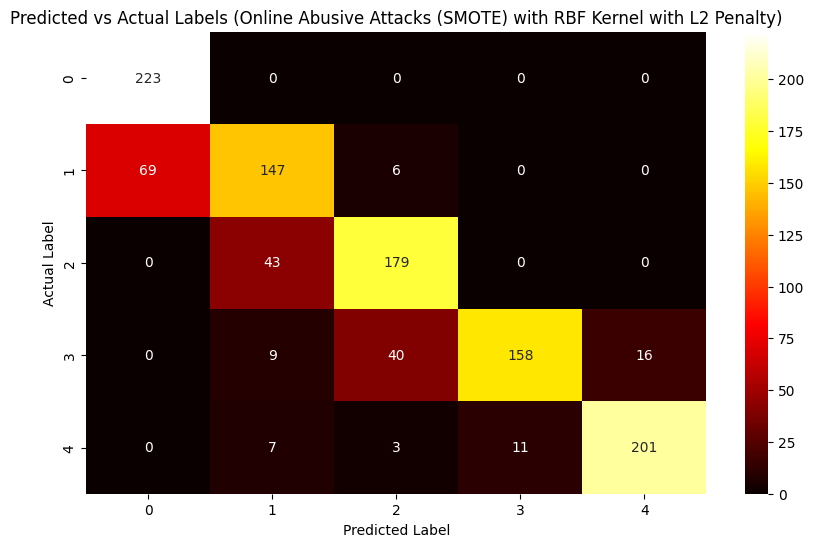

In [107]:
# Plot a heatmap of the predicted vs actual labels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(oaa_y_test, oaa_y_pred_rbf), annot=True, fmt='d', cmap='hot')
plt.title(f'Predicted vs Actual Labels (Online Abusive Attacks ({balance}) with RBF Kernel with L2 Penalty)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

,feature,importance_mean,importance_std
0,Toxic parent tweets,0.597392,0.013472
1,Toxic replies,0.050360,0.004369


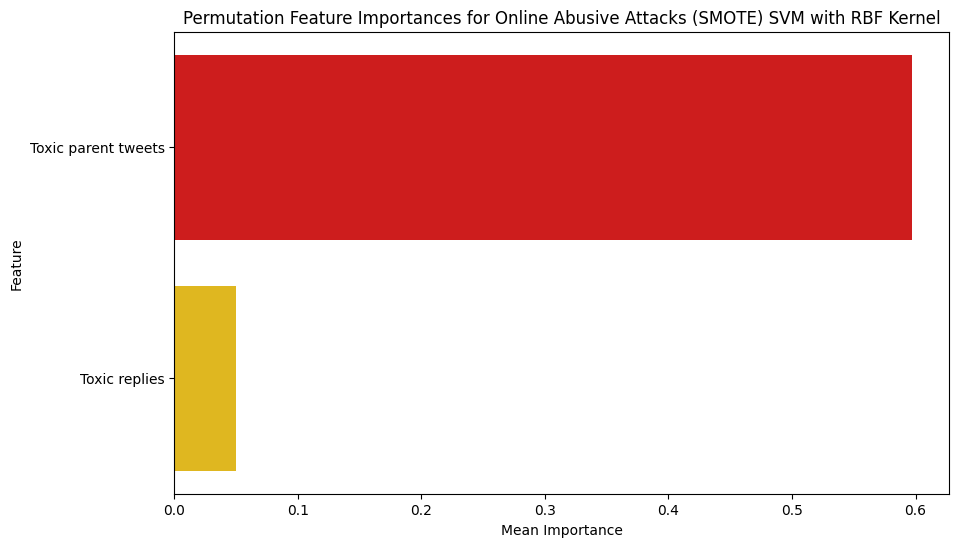

In [108]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(oaa_svm_model_rbf, oaa_X_test, oaa_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
oaa_svm_rbf_perm_importance = pd.DataFrame({
    'feature': oaa_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(oaa_svm_rbf_perm_importance)

# Condense into a dictionary with each feature key and importance mean value
oaa_svm_rbf_perm_importances_dict = oaa_svm_rbf_perm_importance.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=oaa_svm_rbf_perm_importance, palette='hot')
plt.title(f'Permutation Feature Importances for Online Abusive Attacks ({balance}) SVM with RBF Kernel')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [109]:
svm_classification_results_list.append(("Online Abusive Attacks", "RBF", "L2", accuracy_score(oaa_y_test, oaa_y_pred_rbf), f1_score(oaa_y_test, oaa_y_pred_rbf, average='weighted'), oaa_svm_rbf_perm_importances_dict))

In [110]:
oaa_custom_param_grid = {
    "C": np.linspace(0.1, 1, 10),
    "kernel": ["linear", "poly", "rbf"],
    "max_iter": range(1, oaa_max_iter), # range(100, 1000, 100),
    "class_weight": [None]
}

In [111]:
# Train and evaluate the SVM model on the US Accidents Upsampled dataset
oaa_custom_svm_grid_search, oaa_custom_svm_model = svm_grid_search(oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test, oaa_custom_param_grid, oaa_kfold, "oaa_custom_svm_model")

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Parameters tested for oaa_custom_svm_model:
[{'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 1},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 2},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 3},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 4},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 5},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 6},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 7},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 8},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 9},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 10},
 {'C': np.f

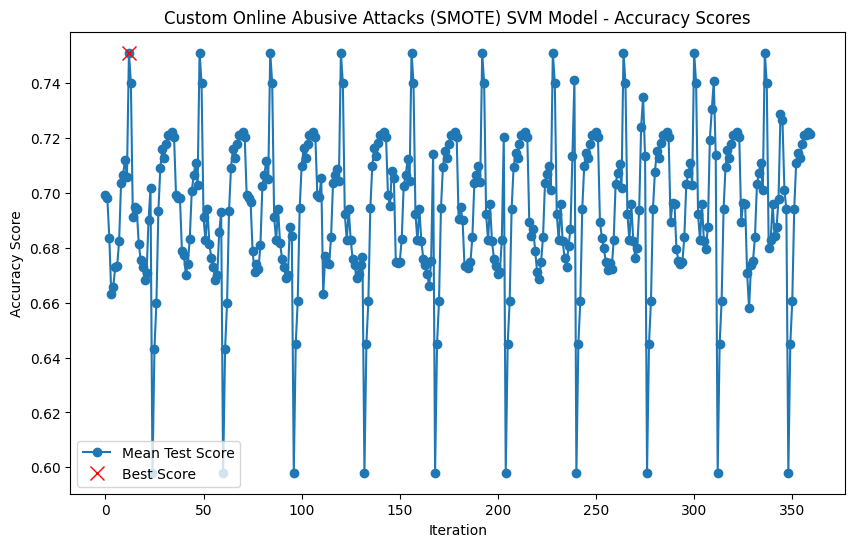

In [112]:
# Plot all accuracy scores for the custom SVM model
plt.figure(figsize=(10, 6))
plt.plot(oaa_custom_svm_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the maximum accuracy score
best_oaa_custom_svm_score_index = np.argmax(oaa_custom_svm_grid_search.cv_results_['mean_test_score'])
plt.plot(best_oaa_custom_svm_score_index, oaa_custom_svm_grid_search.cv_results_['mean_test_score'][best_oaa_custom_svm_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Custom Online Abusive Attacks ({balance}) SVM Model - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [113]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with linear kernel and L1 penalty (from pickled model):")
pprint(oaa_custom_svm_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty (from pickled model):")
print(oaa_custom_svm_grid_search.best_score_)

# Get the best kernel
best_oaa_custom_kernel = oaa_custom_svm_grid_search.best_params_['kernel']
print(f"Best kernel: {best_oaa_custom_kernel}")

Best parameters for SVM with linear kernel and L1 penalty (from pickled model):
{'C': np.float64(0.1), 'class_weight': None, 'kernel': 'poly', 'max_iter': 1}
Best score for SVM with linear kernel and L1 penalty (from pickled model):
0.7511280191099707
Best kernel: poly


In [114]:
# Train the SVM model with the best parameters
oaa_custom_svm_best_model = oaa_custom_svm_grid_search.best_estimator_
oaa_custom_svm_best_model.fit(oaa_X_train, oaa_y_train)

SVC(C=np.float64(0.1), kernel='poly', max_iter=1)

In [115]:
# Use the model to make predictions on the test set
oaa_custom_y_pred = oaa_custom_svm_model.predict(oaa_X_test)

# Print the classification report
print("Classification report for Online Abusive Attacks Upsampled dataset with L1 regularization:")
print(classification_report(oaa_y_test, oaa_custom_y_pred))

Classification report for Online Abusive Attacks Upsampled dataset with L1 regularization:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       223
           1       0.91      0.98      0.94       222
           2       0.00      0.00      0.00       222
           3       0.47      0.91      0.62       223
           4       0.94      0.84      0.89       222

    accuracy                           0.75      1112
   macro avg       0.66      0.75      0.69      1112
weighted avg       0.66      0.75      0.69      1112



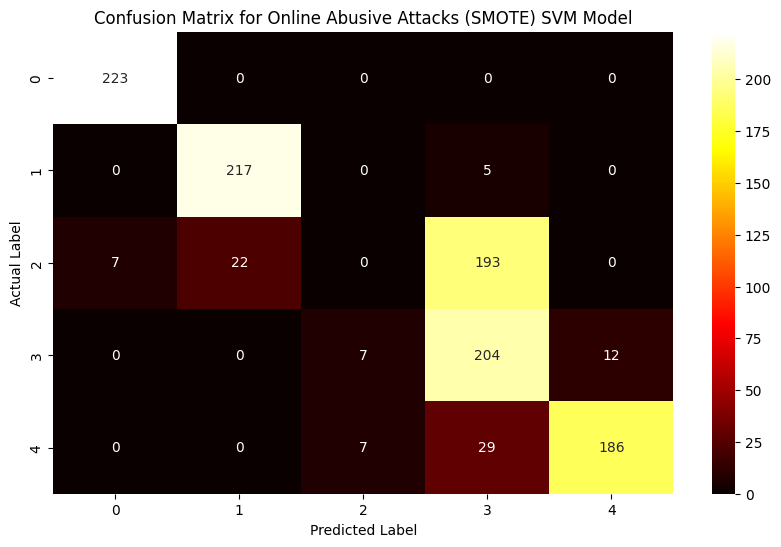

In [116]:
# Plot a heatmap of the predicted vs actual labels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(oaa_y_test, oaa_custom_y_pred, rownames=['Actual Label'], colnames=['Predicted Label']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Online Abusive Attacks ({balance}) SVM Model')
plt.show()

,feature,importance_mean,importance_std
0,Toxic parent tweets,0.495504,0.012112
1,Toxic replies,0.181475,0.006557


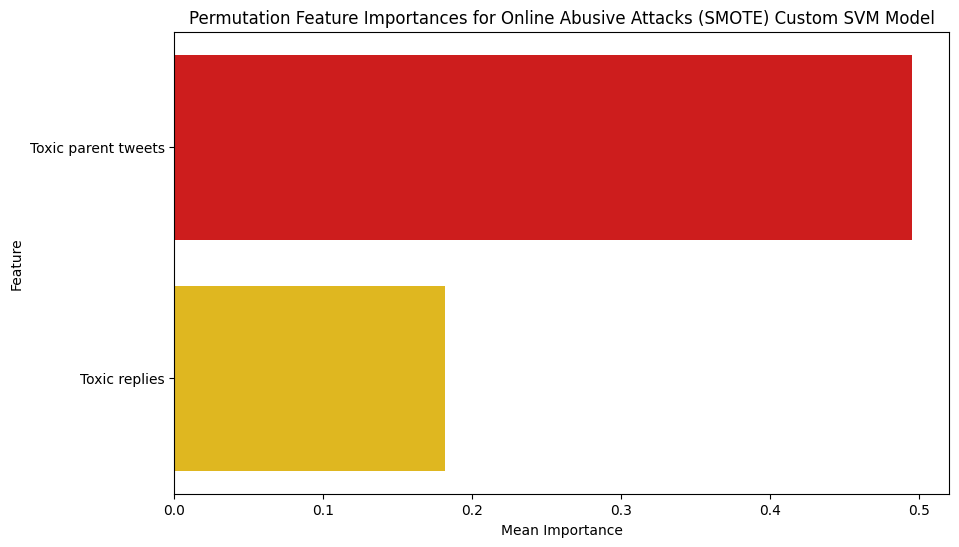

In [117]:
from sklearn.inspection import permutation_importance

# Determine the feature importances using permutation importance
perm_importance = permutation_importance(oaa_custom_svm_best_model, oaa_X_test, oaa_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
oaa_custom_svm_model_perm_importances = pd.DataFrame({
    'feature': oaa_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(oaa_custom_svm_model_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
oaa_custom_svm_model_perm_importances_dict = oaa_custom_svm_model_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=oaa_custom_svm_model_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Online Abusive Attacks ({balance}) Custom SVM Model')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [118]:
# Get the custom model's accuracy and f1-score
oaa_custom_accuracy = accuracy_score(oaa_y_test, oaa_custom_y_pred)
oaa_custom_f1_score = f1_score(oaa_y_test, oaa_custom_y_pred, average='weighted')
print(f"Custom SVM Model Accuracy: {oaa_custom_accuracy}")
print(f"Custom SVM Model F1-Score: {oaa_custom_f1_score}")

Custom SVM Model Accuracy: 0.7464028776978417
Custom SVM Model F1-Score: 0.6873199210174731


In [119]:
svm_classification_results_list.append(("Online Abusive Attacks", best_oaa_custom_kernel, "L1", oaa_custom_accuracy, oaa_custom_f1_score, oaa_custom_svm_model_perm_importances_dict))

In [120]:
svm_classification_results_list

[('Convabuse',
  'Linear',
  'L1',
  0.546954188611746,
  0.5165317953569895,
  {'explicit': 0.11790718473616224,
   'implicit': 0.10125211169631325,
   'system': 0.09774421146775321,
   'bot': 0.0461691344529465,
   'annotator_id': 0.032127596144291025,
   'target_groups': 0.005346318195369226,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'RBF',
  'L2',
  0.5185332405843188,
  0.4544228996956412,
  {'explicit': 0.1814270098380205,
   'implicit': 0.10783066679916531,
   'bot': 0.045910762198151676,
   'system': 0.038865149557785986,
   'target_groups': 0.029245751763887544,
   'annotator_id': 0.005972374043525808,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'linear',
  'L1',
  0.42700983802047104,
  0.2918535391341153,
  {'explicit': 0.09825101858292758,
   'system': 0.09018185431779788,
   'implicit': 0.027606081685382106,
   'bot': 0.0,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': 0.0,
   'annotator_id': -0.01542283613236609}

## US Elections 2020 Hate Speech Support Vector Machines

In [121]:
# Use grid search to find the best hyperparameters for the Linear SVC model
us2020hs_svm_linear_param_grid = {
    'C': np.linspace(0.1, 1, 10), # Regularization parameter
    'loss': ['squared_hinge'], # Loss function
    'max_iter': range(1, us2020hs_max_iter), # range(2, 10), # Maximum number of iterations
    'tol': [1e-4] # Tolerance for stopping criteria
}

In [122]:
us2020hs_svm_linear_grid_search = GridSearchCV(svm.LinearSVC(), us2020hs_svm_linear_param_grid, cv=us2020hs_kfold, scoring='accuracy')
us2020hs_svm_linear_grid_search.fit(us2020hs_X_train, us2020hs_y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(),
             param_grid={'C': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'loss': ['squared_hinge'], 'max_iter': range(1, 13),
                         'tol': [0.0001]},
             scoring='accuracy')

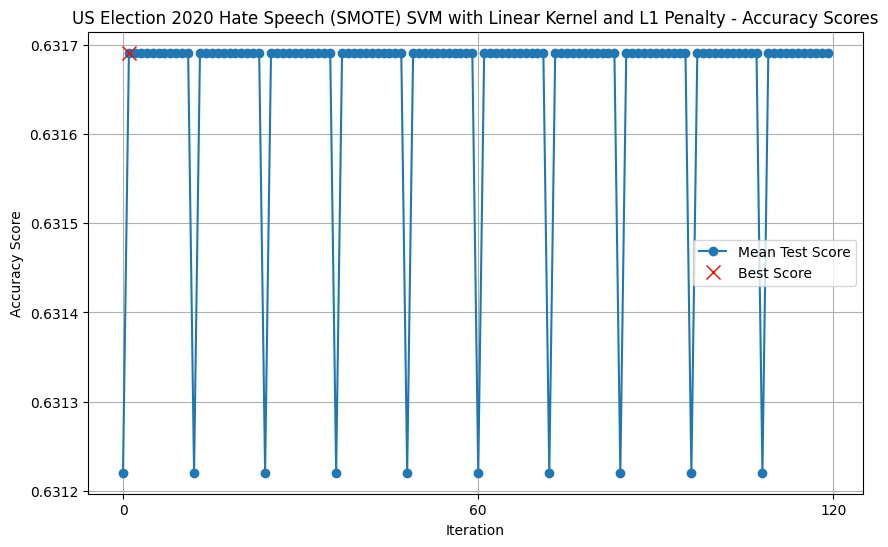

In [123]:
# Plot all accuracy scores for the SVM model with linear kernel and L1 penalty for each iteration
plt.figure(figsize=(10, 6))
plt.plot(us2020hs_svm_linear_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
us2020hs_linear_best_score_index = np.argmax(us2020hs_svm_linear_grid_search.cv_results_['mean_test_score'])
plt.plot(us2020hs_linear_best_score_index, us2020hs_svm_linear_grid_search.cv_results_['mean_test_score'][us2020hs_linear_best_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'US Election 2020 Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.xticks([0, (len(us2020hs_svm_linear_grid_search.cv_results_['mean_test_score'])) / 2, len(us2020hs_svm_linear_grid_search.cv_results_['mean_test_score'])])
plt.grid()
plt.legend()
plt.show()

In [124]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(us2020hs_svm_linear_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(us2020hs_svm_linear_grid_search.best_score_)

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.1), 'loss': 'squared_hinge', 'max_iter': 2, 'tol': 0.0001}
Best score for SVM with linear kernel and L1 penalty:
0.6316912981295044


In [125]:
# Train the SVM model with the best parameters
us2020hs_svm_model_linear = svm.LinearSVC(**us2020hs_svm_linear_grid_search.best_params_, random_state=42)
us2020hs_svm_model_linear.fit(us2020hs_X_train, us2020hs_y_train)

LinearSVC(C=np.float64(0.1), max_iter=2, random_state=42)

In [126]:
# Print the classification report for the us2020hs_svm_model_linear model
us2020hs_y_pred_linear = us2020hs_svm_model_linear.predict(us2020hs_X_test)
print("Classification report for SVM with linear kernel and L1 penalty:")
print(classification_report(us2020hs_y_test, us2020hs_y_pred_linear))
print(f"F1 Score: {f1_score(us2020hs_y_test, us2020hs_y_pred_linear, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(us2020hs_y_test, us2020hs_y_pred_linear):.4f}")

Classification report for SVM with linear kernel and L1 penalty:
              precision    recall  f1-score   support

           0       0.65      0.64      0.65       528
           1       0.65      0.65      0.65       528

    accuracy                           0.65      1056
   macro avg       0.65      0.65      0.65      1056
weighted avg       0.65      0.65      0.65      1056

F1 Score: 0.6487
Accuracy: 0.6487


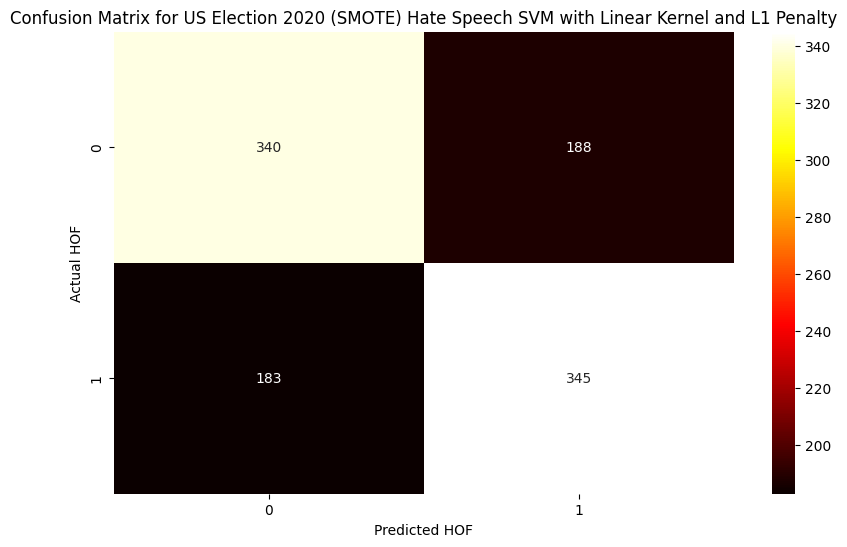

In [127]:
# Plot a heatmap of the actual vs predicted HOF for the us_accidents_svm_model_linear model
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(us2020hs_y_test, us2020hs_y_pred_linear, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for US Election 2020 ({balance}) Hate Speech SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Predicted HOF')
plt.ylabel('Actual HOF')
plt.show()

,feature,importance_mean,importance_std
1,Biden,0.116098,0.014653
0,Trump,0.073958,0.006939
2,West,0.000000,0.000000


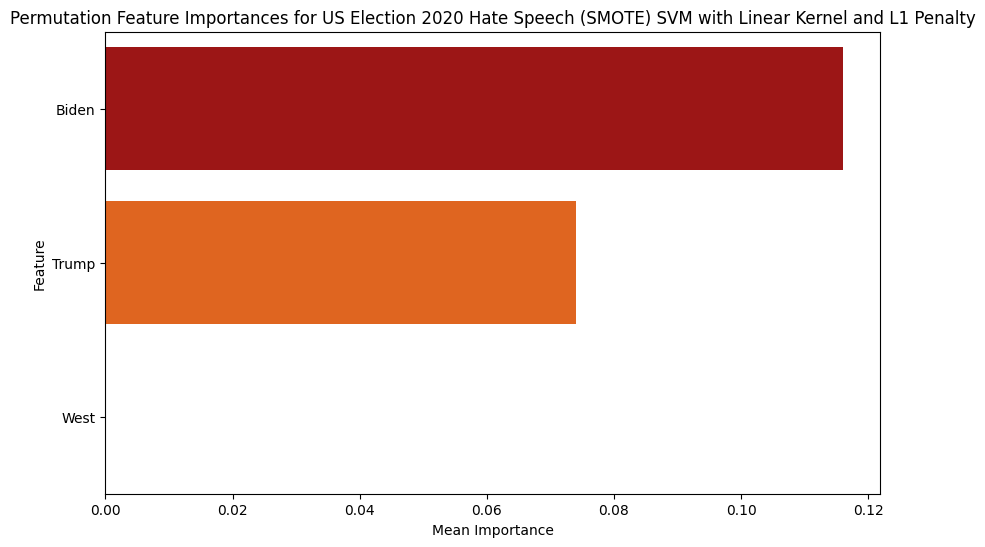

In [128]:
from sklearn.inspection import permutation_importance

# Determine the feature importances
perm_importance = permutation_importance(us2020hs_svm_model_linear, us2020hs_X_test, us2020hs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
us2020hs_svm_model_linear_perm_importances = pd.DataFrame({
    'feature': us2020hs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(us2020hs_svm_model_linear_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
us2020hs_svm_model_linear_perm_importances_dict = us2020hs_svm_model_linear_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=us2020hs_svm_model_linear_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for US Election 2020 Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [129]:
svm_classification_results_list.append(("US Elections 2020 Election Hate Speech", "Linear", "L1", accuracy_score(us2020hs_y_test, us2020hs_y_pred_linear), f1_score(us2020hs_y_test, us2020hs_y_pred_linear, average='weighted'), us2020hs_svm_model_linear_perm_importances_dict))

In [130]:
us2020hs_svm_rbf_pipeline = Pipeline([
    ("kernel", RBFSampler()),
    ("clf", SGDClassifier(loss="hinge", random_state=42, penalty="l2", tol=1e-4))
])

In [131]:
# Use grid search to find the best hyperparameters for the SVM model
us2020hs_svm_rbf_param_grid = {
    'kernel__gamma': np.linspace(0.1, 1, 10), # Kernel coefficient,
    'kernel__n_components': range(2, us2020hs_X_train.shape[1] + 1), # Number of components for the RBF kernel
    'clf__alpha': [1e-4], # Regularization parameter
    'clf__max_iter': range(1, us2020hs_max_iter), # range(820, 840), # Maximum number of iterations
    'clf__tol': [1e-4], # Tolerance for stopping criteria
    'clf__early_stopping': [True] # Whether to use early stopping
}

In [132]:
# Perform a grid search using the RBFSampler
us2020hs_svm_rbf_grid_search = GridSearchCV(
    estimator=us2020hs_svm_rbf_pipeline,
    param_grid=
    us2020hs_svm_rbf_param_grid,
    cv=us2020hs_kfold,
    scoring='accuracy',
    n_jobs=2,
    verbose=True
)

In [133]:
# Fit the grid search to the training data
us2020hs_svm_rbf_grid_search.fit(us2020hs_X_train, us2020hs_y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('kernel', RBFSampler()),
                                       ('clf',
                                        SGDClassifier(random_state=42,
                                                      tol=0.0001))]),
             n_jobs=2,
             param_grid={'clf__alpha': [0.0001], 'clf__early_stopping': [True],
                         'clf__max_iter': range(1, 13), 'clf__tol': [0.0001],
                         'kernel__gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'kernel__n_components': range(2, 4)},
             scoring='accuracy', verbose=True)

In [134]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with RBF kernel:")
pprint(us2020hs_svm_rbf_grid_search.best_params_)
print("Best score for SVM with RBF kernel:")
print(us2020hs_svm_rbf_grid_search.best_score_)

Best parameters for SVM with RBF kernel:
{'clf__alpha': 0.0001,
 'clf__early_stopping': True,
 'clf__max_iter': 10,
 'clf__tol': 0.0001,
 'kernel__gamma': np.float64(0.30000000000000004),
 'kernel__n_components': 3}
Best score for SVM with RBF kernel:
0.6703014666704059


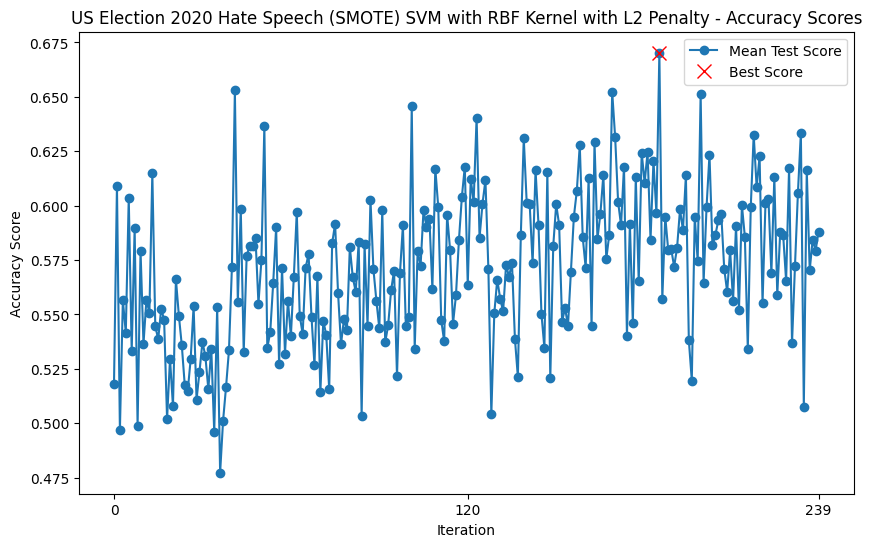

In [135]:
# Plot all accuracy scores for the SVM model with RBF kernel for each iteration
plt.figure(figsize=(10, 6))
plt.plot(us2020hs_svm_rbf_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
best_us2020hs_svm_rbf_score_index = np.argmax(us2020hs_svm_rbf_grid_search.cv_results_['mean_test_score'])
plt.plot(best_us2020hs_svm_rbf_score_index, us2020hs_svm_rbf_grid_search.cv_results_['mean_test_score'][best_us2020hs_svm_rbf_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'US Election 2020 Hate Speech ({balance}) SVM with RBF Kernel with L2 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')

# Only plot x-axis ticks of 0, the median, and the last iteration
plt.xticks([0, len(us2020hs_svm_rbf_grid_search.cv_results_['mean_test_score']) // 2, len(us2020hs_svm_rbf_grid_search.cv_results_['mean_test_score']) - 1])

plt.legend()
plt.show()

In [136]:
# Train the SVM model with the best parameters
us2020hs_svm_model_rbf = us2020hs_svm_rbf_grid_search.best_estimator_
us2020hs_svm_model_rbf.fit(us2020hs_X_train, us2020hs_y_train)

Pipeline(steps=[('kernel',
                 RBFSampler(gamma=np.float64(0.30000000000000004),
                            n_components=3)),
                ('clf',
                 SGDClassifier(early_stopping=True, max_iter=10,
                               random_state=42, tol=0.0001))])

In [137]:
# Print the classification report for the us2020hs_svm_model_rbf model
us2020hs_y_pred_rbf = us2020hs_svm_model_rbf.predict(us2020hs_X_test)
print("Classification report for SVM with RBF kernel:")
print(classification_report(us2020hs_y_test, us2020hs_y_pred_rbf))
print(f"F1 Score: {f1_score(us2020hs_y_test, us2020hs_y_pred_rbf, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(us2020hs_y_test, us2020hs_y_pred_rbf):.4f}")

Classification report for SVM with RBF kernel:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       528
           1       0.68      0.64      0.66       528

    accuracy                           0.67      1056
   macro avg       0.67      0.67      0.67      1056
weighted avg       0.67      0.67      0.67      1056

F1 Score: 0.6730
Accuracy: 0.6733


In [138]:
us2020hs_y_test.value_counts()

,count
HOF,
1,528
0,528


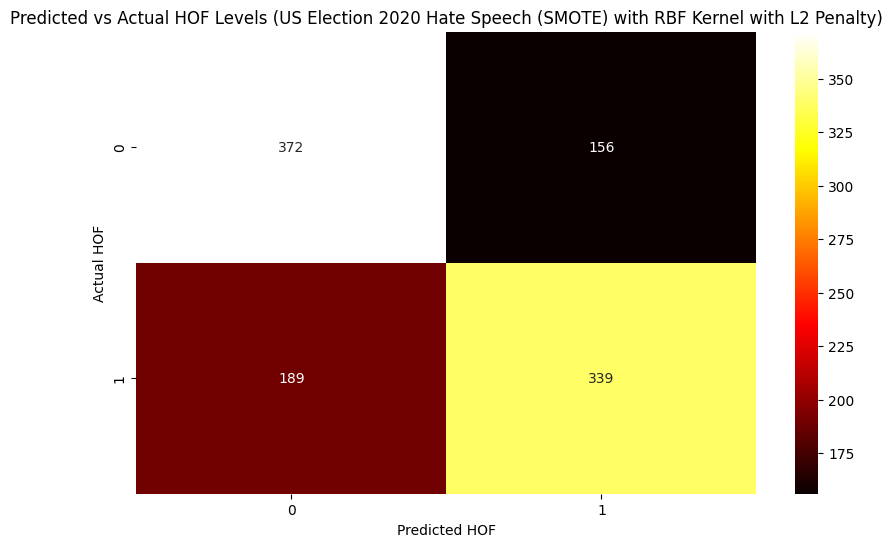

In [139]:
# Plot a heatmap of the predicted vs actual HOF levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(us2020hs_y_test, us2020hs_y_pred_rbf), annot=True, fmt='d', cmap='hot')
plt.title(f'Predicted vs Actual HOF Levels (US Election 2020 Hate Speech ({balance}) with RBF Kernel with L2 Penalty)')
plt.xlabel('Predicted HOF')
plt.ylabel('Actual HOF')
plt.show()

,feature,importance_mean,importance_std
1,Biden,0.151231,0.008628
0,Trump,0.120455,0.013148
2,West,0.000000,0.000000


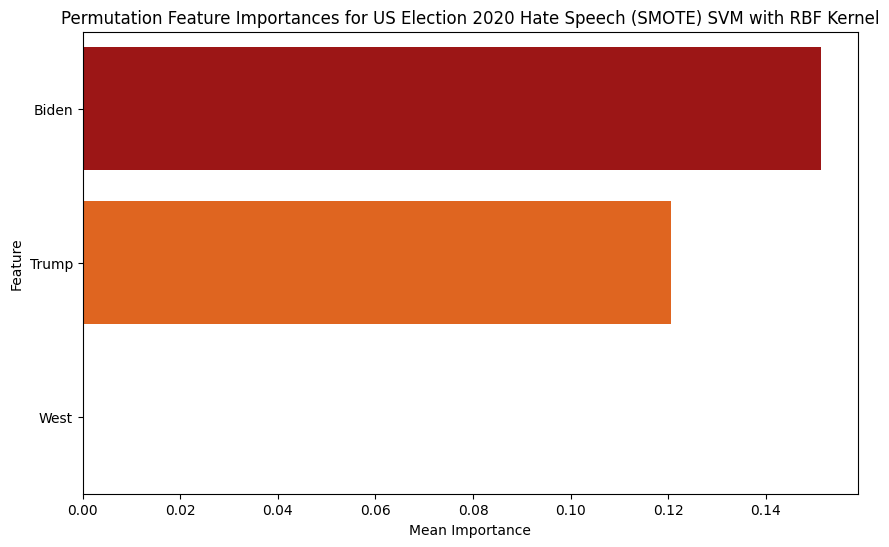

In [140]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(us2020hs_svm_model_rbf, us2020hs_X_test, us2020hs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
us2020hs_svm_rbf_perm_importance = pd.DataFrame({
    'feature': us2020hs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(us2020hs_svm_rbf_perm_importance)

# Condense into a dictionary with each feature key and importance mean value
us2020hs_svm_rbf_perm_importances_dict = us2020hs_svm_rbf_perm_importance.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=us2020hs_svm_rbf_perm_importance, palette='hot')
plt.title(f'Permutation Feature Importances for US Election 2020 Hate Speech ({balance}) SVM with RBF Kernel')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [141]:
svm_classification_results_list.append(("US Elections 2020 Election Hate Speech", "RBF", "L2", accuracy_score(us2020hs_y_test, us2020hs_y_pred_rbf), f1_score(us2020hs_y_test, us2020hs_y_pred_rbf, average='weighted'), us2020hs_svm_rbf_perm_importances_dict))

In [142]:
us2020hs_custom_param_grid = {
    "C": np.linspace(0.1, 1, 10),
    "kernel": ["linear", "poly", "rbf"],
    "max_iter": range(1, us2020hs_max_iter), # range(160, 200),
    "class_weight": ["balanced", None]
}

In [143]:
# Train and evaluate the SVM model on the US Accidents Upsampled dataset
us2020hs_custom_svm_grid_search, us2020hs_custom_svm_model = svm_grid_search(us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test, us2020hs_custom_param_grid, us2020hs_kfold, "us2020hs_custom_svm_model")

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Parameters tested for us2020hs_custom_svm_model:
[{'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 1},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 2},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 3},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 4},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 5},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 6},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 7},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 8},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 9},
 {'C': np.float64(0.1),
  'class_weight':

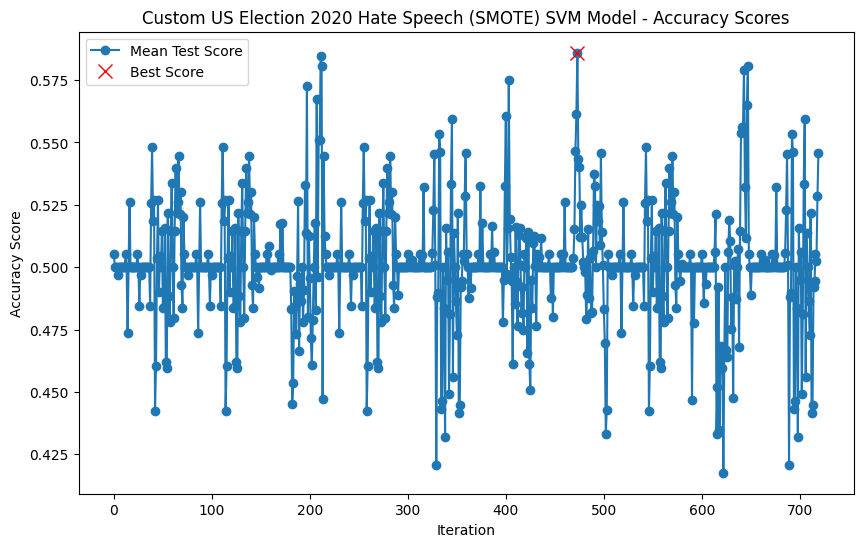

In [144]:
# Plot all accuracy scores for the custom SVM model
plt.figure(figsize=(10, 6))
plt.plot(us2020hs_custom_svm_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the maximum accuracy score
best_us2020hs_custom_svm_score_index = np.argmax(us2020hs_custom_svm_grid_search.cv_results_['mean_test_score'])
plt.plot(best_us2020hs_custom_svm_score_index, us2020hs_custom_svm_grid_search.cv_results_['mean_test_score'][best_us2020hs_custom_svm_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Custom US Election 2020 Hate Speech ({balance}) SVM Model - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [145]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(us2020hs_custom_svm_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(us2020hs_custom_svm_grid_search.best_score_)

# Get the best kernel
best_us2020hs_custom_kernel = us2020hs_custom_svm_grid_search.best_params_['kernel']

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.7000000000000001),
 'class_weight': None,
 'kernel': 'linear',
 'max_iter': 6}
Best score for SVM with linear kernel and L1 penalty:
0.5859942791441151


In [146]:
# Train the SVM model with the best parameters
us2020hs_custom_svm_best_params = us2020hs_custom_svm_grid_search.best_params_.copy()
us2020hs_custom_svm_best_params.pop('kernel', None) # Remove the kernel key if it exists
us2020hs_custom_svm_best_model = us2020hs_custom_svm_grid_search.best_estimator_
us2020hs_custom_svm_best_model.fit(us2020hs_X_train, us2020hs_y_train)

SVC(C=np.float64(0.7000000000000001), kernel='linear', max_iter=6)

In [147]:
# Use the model to make predictions on the test set
us2020hs_custom_y_pred = us2020hs_custom_svm_best_model.predict(us2020hs_X_test)

# Print the classification report
print("Classification report for US Accidents Upsampled dataset with L1 regularization:")
print(classification_report(us2020hs_y_test, us2020hs_custom_y_pred))

Classification report for US Accidents Upsampled dataset with L1 regularization:
              precision    recall  f1-score   support

           0       0.59      0.31      0.41       528
           1       0.53      0.78      0.63       528

    accuracy                           0.55      1056
   macro avg       0.56      0.55      0.52      1056
weighted avg       0.56      0.55      0.52      1056



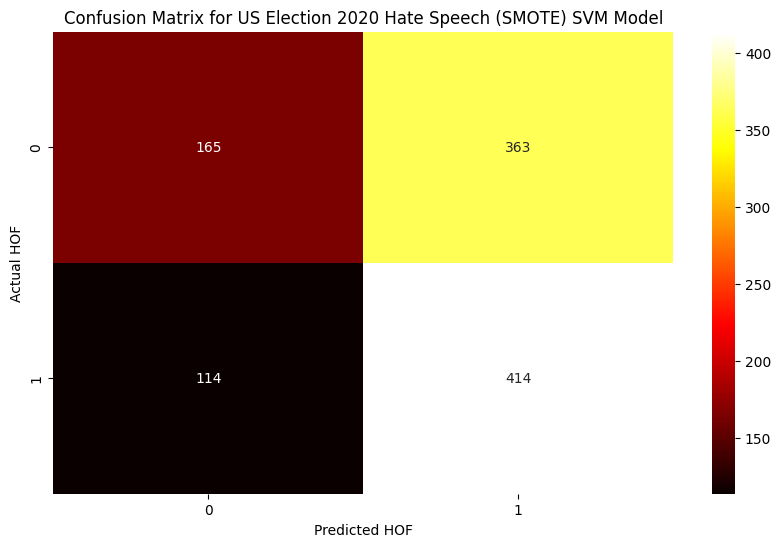

In [148]:
# Plot a heatmap of the predicted vs actual HOF levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(us2020hs_y_test, us2020hs_custom_y_pred, rownames=['Actual HOF'], colnames=['Predicted HOF']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for US Election 2020 Hate Speech ({balance}) SVM Model')
plt.show()

,feature,importance_mean,importance_std
0,Trump,0.060795,0.009487
1,Biden,0.024905,0.014217
2,West,0.000000,0.000000


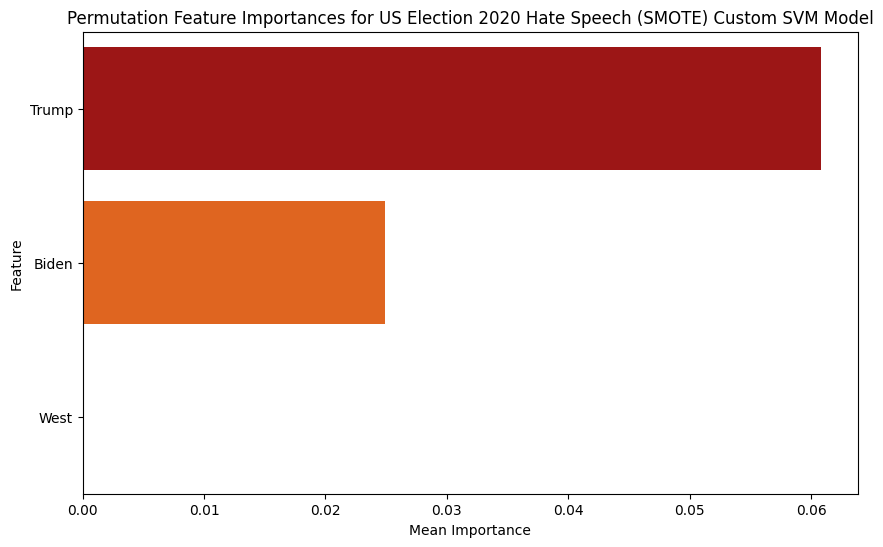

In [149]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(us2020hs_custom_svm_best_model, us2020hs_X_test, us2020hs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
us2020hs_custom_svm_perm_importances = pd.DataFrame({
    'feature': us2020hs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(us2020hs_custom_svm_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
us2020hs_custom_svm_perm_importances_dict = us2020hs_custom_svm_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=us2020hs_custom_svm_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for US Election 2020 Hate Speech ({balance}) Custom SVM Model')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [150]:
# Get the custom model's accuracy and f1-score
us2020hs_custom_accuracy = accuracy_score(us2020hs_y_test, us2020hs_custom_y_pred)
us2020hs_custom_f1_score = f1_score(us2020hs_y_test, us2020hs_custom_y_pred, average='weighted')
print(f"Custom SVM Model Accuracy: {us2020hs_custom_accuracy}")
print(f"Custom SVM Model F1-Score: {us2020hs_custom_f1_score}")

Custom SVM Model Accuracy: 0.5482954545454546
Custom SVM Model F1-Score: 0.5217023458530957


In [151]:
svm_classification_results_list.append(("US Elections 2020 Election Hate Speech", best_us2020hs_custom_kernel, "L1", us2020hs_custom_accuracy, us2020hs_custom_f1_score, us2020hs_custom_svm_perm_importances_dict))

In [152]:
svm_classification_results_list

[('Convabuse',
  'Linear',
  'L1',
  0.546954188611746,
  0.5165317953569895,
  {'explicit': 0.11790718473616224,
   'implicit': 0.10125211169631325,
   'system': 0.09774421146775321,
   'bot': 0.0461691344529465,
   'annotator_id': 0.032127596144291025,
   'target_groups': 0.005346318195369226,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'RBF',
  'L2',
  0.5185332405843188,
  0.4544228996956412,
  {'explicit': 0.1814270098380205,
   'implicit': 0.10783066679916531,
   'bot': 0.045910762198151676,
   'system': 0.038865149557785986,
   'target_groups': 0.029245751763887544,
   'annotator_id': 0.005972374043525808,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'linear',
  'L1',
  0.42700983802047104,
  0.2918535391341153,
  {'explicit': 0.09825101858292758,
   'system': 0.09018185431779788,
   'implicit': 0.027606081685382106,
   'bot': 0.0,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': 0.0,
   'annotator_id': -0.01542283613236609}

## MLMA Hate Speech Support Vector Machines

In [153]:
# Use grid search to find the best hyperparameters for the Linear SVC model
mlma_hate_speech_svm_linear_param_grid = {
    'C': np.linspace(0.1, 1, 10), # Regularization parameter
    'loss': ['squared_hinge'], # Loss function
    'max_iter': range(1, mlma_hate_speech_max_iter), # range(2, 10), # Maximum number of iterations
    'tol': [1e-4] # Tolerance for stopping criteria
}

In [154]:
# Get a 30% sample of mlma_hate_speech
mlma_hate_speech_sample = mlma_hate_speech.sample(frac=0.3, random_state=42)

# X and y
mlma_hate_speech_X_sample = mlma_hate_speech_sample.drop('target_groups', axis=1)
mlma_hate_speech_y_sample = mlma_hate_speech_sample['target_groups']

# Standard scale
mlma_hate_speech_X_sample_scaled = StandardScaler().fit_transform(mlma_hate_speech_X_sample)
mlma_hate_speech_X_sample_scaled = pd.DataFrame(mlma_hate_speech_X_sample_scaled, columns=mlma_hate_speech_X_sample.columns)

# Train test split
mlma_hate_speech_X_train_sample, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_train_sample, mlma_hate_speech_y_test_sample = train_test_split(mlma_hate_speech_X_sample_scaled, mlma_hate_speech_y_sample, test_size=0.2, random_state=42)

In [155]:
mlma_hate_speech_svm_linear_grid_search = GridSearchCV(svm.LinearSVC(), mlma_hate_speech_svm_linear_param_grid, cv=mlma_hate_speech_kfold, scoring='accuracy')
mlma_hate_speech_svm_linear_grid_search.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(),
             param_grid={'C': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'loss': ['squared_hinge'], 'max_iter': range(1, 16),
                         'tol': [0.0001]},
             scoring='accuracy')

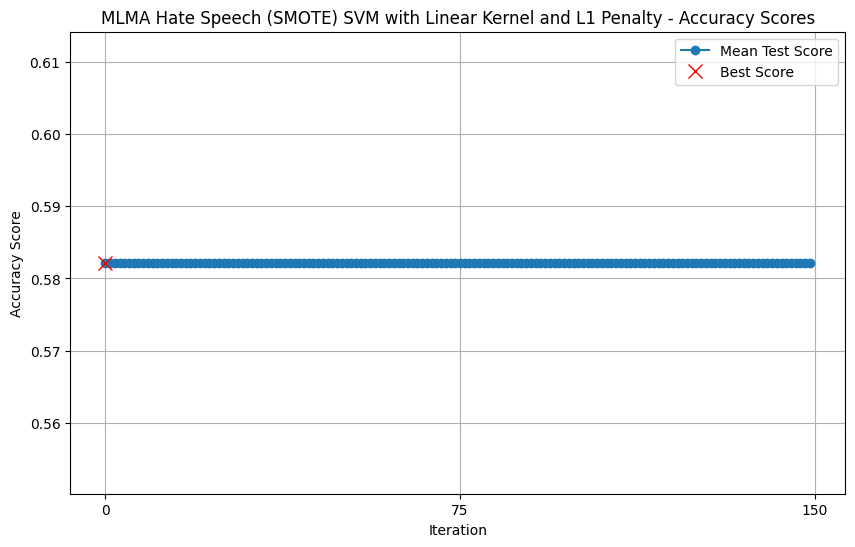

In [156]:
# Plot all accuracy scores for the SVM model with linear kernel and L1 penalty for each iteration
plt.figure(figsize=(10, 6))
plt.plot(mlma_hate_speech_svm_linear_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
mlma_hate_speech_linear_best_score_index = np.argmax(mlma_hate_speech_svm_linear_grid_search.cv_results_['mean_test_score'])
plt.plot(mlma_hate_speech_linear_best_score_index, mlma_hate_speech_svm_linear_grid_search.cv_results_['mean_test_score'][mlma_hate_speech_linear_best_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'MLMA Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.xticks([0, len(mlma_hate_speech_svm_linear_grid_search.cv_results_['mean_test_score']) / 2, len(mlma_hate_speech_svm_linear_grid_search.cv_results_['mean_test_score'])])
plt.grid()
plt.legend()
plt.show()

In [157]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(mlma_hate_speech_svm_linear_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(mlma_hate_speech_svm_linear_grid_search.best_score_)

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.1), 'loss': 'squared_hinge', 'max_iter': 1, 'tol': 0.0001}
Best score for SVM with linear kernel and L1 penalty:
0.5821810155626496


In [158]:
# Train the SVM model with the best parameters
mlma_hate_speech_svm_model_linear = svm.LinearSVC(**mlma_hate_speech_svm_linear_grid_search.best_params_, random_state=42)
mlma_hate_speech_svm_model_linear.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)

LinearSVC(C=np.float64(0.1), max_iter=1, random_state=42)

In [159]:
mlma_hate_speech_y_pred_linear = mlma_hate_speech_svm_model_linear.predict(mlma_hate_speech_X_test_sample)
print("Classification report for SVM with linear kernel and L1 penalty:")
print(classification_report(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear))
print(f"F1 Score: {f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear):.4f}")

Classification report for SVM with linear kernel and L1 penalty:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       277
           1       0.57      1.00      0.73       644
           2       0.00      0.00      0.00       177
           3       0.00      0.00      0.00        22

    accuracy                           0.57      1120
   macro avg       0.14      0.25      0.18      1120
weighted avg       0.33      0.57      0.42      1120

F1 Score: 0.4198
Accuracy: 0.5750


In [160]:
len(mlma_hate_speech_X_train), len(mlma_hate_speech_y_train), len(mlma_hate_speech_y_pred_linear)

(34684, 34684, 1120)

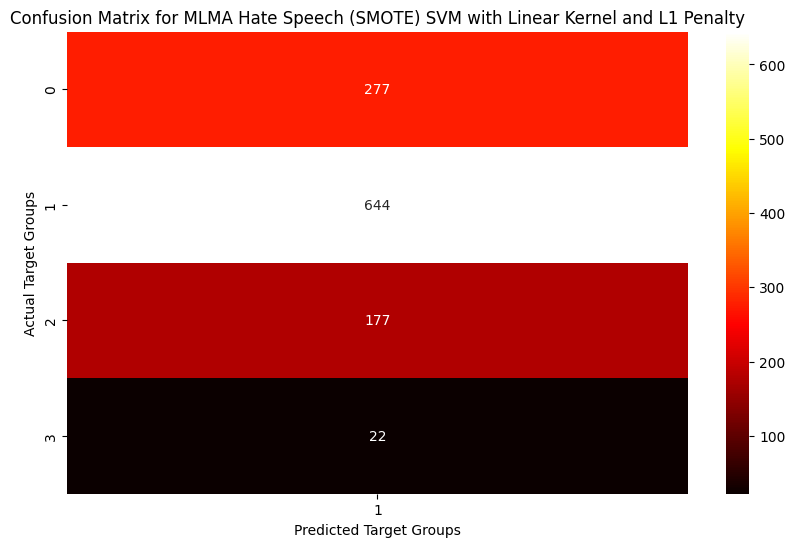

In [161]:
# Plot a heatmap of the actual vs predicted HOF for the mlma_hate_speech_svm_model_linear model
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for MLMA Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Predicted Target Groups')
plt.ylabel('Actual Target Groups')
plt.show()

,feature,importance_mean,importance_std
0,implicit,0.0,0.0
1,explicit,0.0,0.0
2,annotator_sentiment,0.0,0.0
3,abuse_level,0.0,0.0


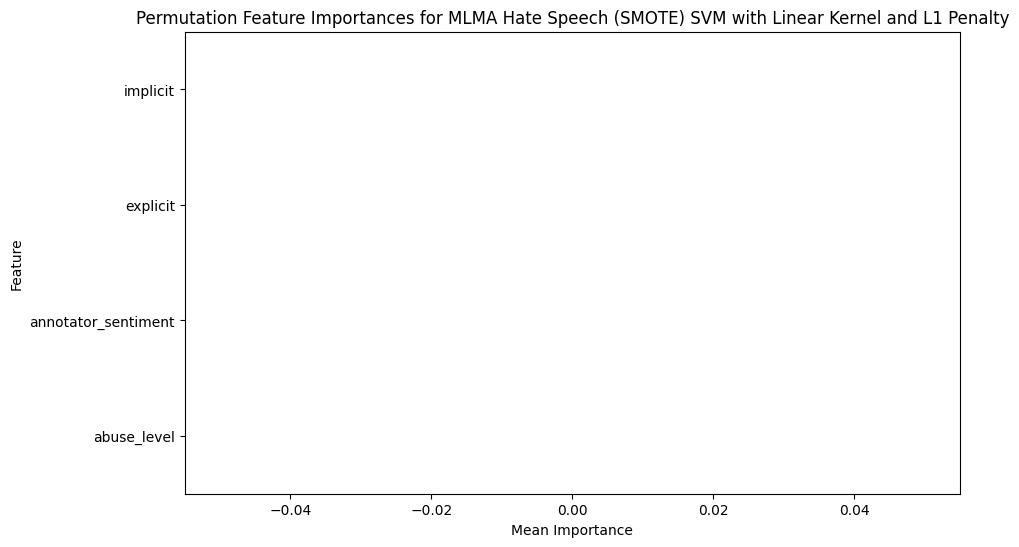

In [162]:
# Determine the feature importances
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(mlma_hate_speech_svm_model_linear, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_test_sample, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
mlma_hate_speech_svm_model_linear_perm_importances = pd.DataFrame({
    'feature': mlma_hate_speech_X_test_sample.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(mlma_hate_speech_svm_model_linear_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
mlma_hate_speech_svm_model_linear_perm_importances_dict = mlma_hate_speech_svm_model_linear_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=mlma_hate_speech_svm_model_linear_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for MLMA Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [163]:
svm_classification_results_list.append(("MLMA Hate Speech", "Linear", "L1", accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear), f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear, average='weighted'), mlma_hate_speech_svm_model_linear_perm_importances_dict))

In [164]:
mlma_hate_speech_svm_rbf_pipeline = Pipeline([
    ("kernel", RBFSampler()),
    ("clf", SGDClassifier(loss="hinge", random_state=42, penalty="l2", tol=1e-4))
])

In [165]:
mlma_hate_speech_max_iter

16

In [166]:
# Use grid search to find the best hyperparameters for the SVM model
mlma_hate_speech_svm_rbf_param_grid = {
    'kernel__gamma': np.linspace(0.1, 1, 10), # Kernel coefficient,
    'kernel__n_components': range(2, mlma_hate_speech_X_train.shape[1] + 1), # Number of components for the RBF kernel
    'clf__alpha': [1e-4], # Regularization parameter
    'clf__max_iter': range(1, mlma_hate_speech_max_iter), # range(470, 495, 5), # Maximum number of iterations
    'clf__tol': [1e-4], # Tolerance for stopping criteria
    'clf__early_stopping': [True] # Whether to use early stopping
}

In [167]:
# Perform a grid search using the RBFSampler
mlma_hate_speech_svm_rbf_grid_search = GridSearchCV(
    estimator=mlma_hate_speech_svm_rbf_pipeline,
    param_grid=
    mlma_hate_speech_svm_rbf_param_grid,
    cv=mlma_hate_speech_kfold,
    scoring='accuracy',
    n_jobs=2,
    verbose=True
)

In [168]:
# Fit the grid search to the training data
mlma_hate_speech_svm_rbf_grid_search.fit(mlma_hate_speech_X_train, mlma_hate_speech_y_train)

Fitting 5 folds for each of 450 candidates, totalling 2250 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('kernel', RBFSampler()),
                                       ('clf',
                                        SGDClassifier(random_state=42,
                                                      tol=0.0001))]),
             n_jobs=2,
             param_grid={'clf__alpha': [0.0001], 'clf__early_stopping': [True],
                         'clf__max_iter': range(1, 16), 'clf__tol': [0.0001],
                         'kernel__gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'kernel__n_components': range(2, 5)},
             scoring='accuracy', verbose=True)

In [169]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with RBF kernel:")
pprint(mlma_hate_speech_svm_rbf_grid_search.best_params_)
print("Best score for SVM with RBF kernel:")
print(mlma_hate_speech_svm_rbf_grid_search.best_score_)

Best parameters for SVM with RBF kernel:
{'clf__alpha': 0.0001,
 'clf__early_stopping': True,
 'clf__max_iter': 11,
 'clf__tol': 0.0001,
 'kernel__gamma': np.float64(0.2),
 'kernel__n_components': 4}
Best score for SVM with RBF kernel:
0.39799224076168127


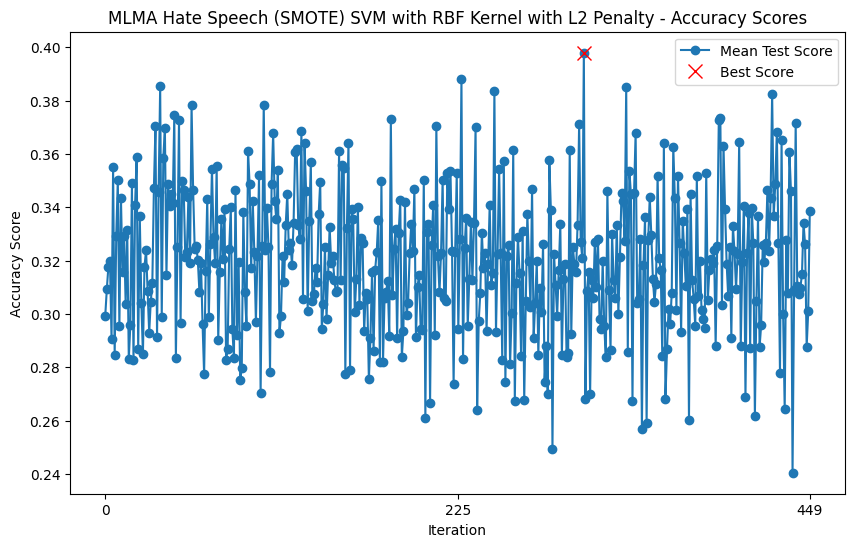

In [170]:
# Plot all accuracy scores for the SVM model with RBF kernel for each iteration
plt.figure(figsize=(10, 6))
plt.plot(mlma_hate_speech_svm_rbf_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
best_mlma_hate_speech_svm_rbf_score_index = np.argmax(mlma_hate_speech_svm_rbf_grid_search.cv_results_['mean_test_score'])
plt.plot(best_mlma_hate_speech_svm_rbf_score_index, mlma_hate_speech_svm_rbf_grid_search.cv_results_['mean_test_score'][best_mlma_hate_speech_svm_rbf_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'MLMA Hate Speech ({balance}) SVM with RBF Kernel with L2 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')

# Only plot x-axis ticks of 0, the median, and the last iteration
plt.xticks([0, len(mlma_hate_speech_svm_rbf_grid_search.cv_results_['mean_test_score']) // 2, len(mlma_hate_speech_svm_rbf_grid_search.cv_results_['mean_test_score']) - 1])

plt.legend()
plt.show()

In [171]:
# Train the SVM model with the best parameters
mlma_hate_speech_svm_model_rbf = mlma_hate_speech_svm_rbf_grid_search.best_estimator_
mlma_hate_speech_svm_model_rbf.fit(mlma_hate_speech_X_train, mlma_hate_speech_y_train)

Pipeline(steps=[('kernel', RBFSampler(gamma=np.float64(0.2), n_components=4)),
                ('clf',
                 SGDClassifier(early_stopping=True, max_iter=11,
                               random_state=42, tol=0.0001))])

In [172]:
# Print the classification report for the mlma_hate_speech_svm_model_rbf model
mlma_hate_speech_y_pred_rbf = mlma_hate_speech_svm_model_rbf.predict(mlma_hate_speech_X_test)
print("Classification report for SVM with RBF kernel:")
print(classification_report(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf))
print(f"F1 Score: {f1_score(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf):.4f}")

Classification report for SVM with RBF kernel:
              precision    recall  f1-score   support

           0       0.54      0.24      0.33      2168
           1       0.21      0.07      0.10      2168
           2       0.36      0.05      0.08      2168
           3       0.27      0.85      0.42      2168

    accuracy                           0.30      8672
   macro avg       0.35      0.30      0.23      8672
weighted avg       0.35      0.30      0.23      8672

F1 Score: 0.2334
Accuracy: 0.3014


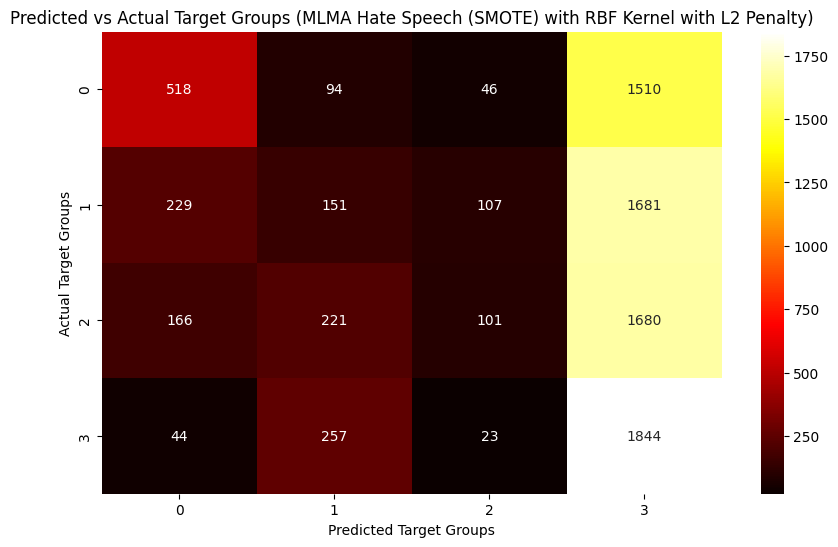

In [173]:
# Plot a heatmap of the predicted vs actual HOF levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf), annot=True, fmt='d', cmap='hot')
plt.title(f'Predicted vs Actual Target Groups (MLMA Hate Speech ({balance}) with RBF Kernel with L2 Penalty)')
plt.xlabel('Predicted Target Groups')
plt.ylabel('Actual Target Groups')
plt.show()

,feature,importance_mean,importance_std
0,implicit,0.069615,0.003883
1,explicit,0.046518,0.005063
2,annotator_sentiment,0.039149,0.004085
3,abuse_level,0.001257,0.002002


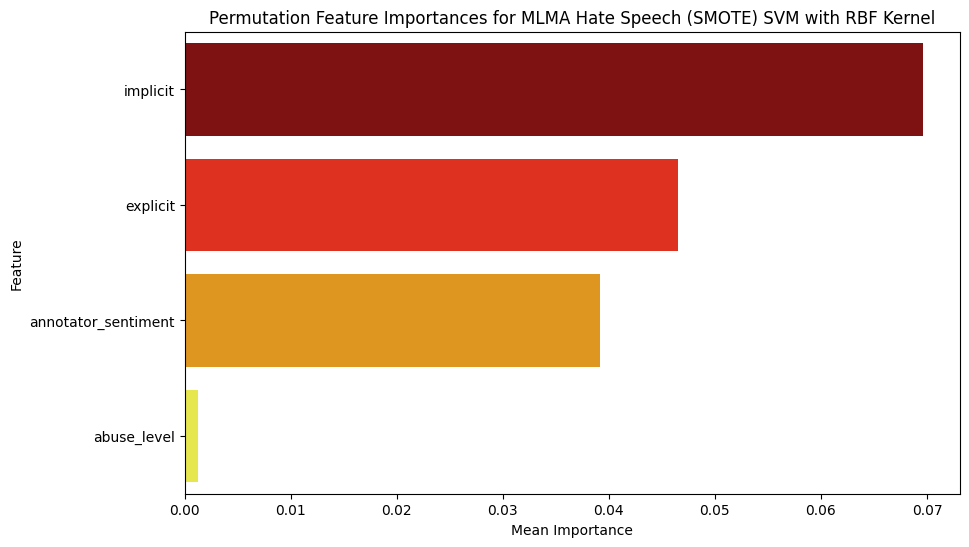

In [174]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(mlma_hate_speech_svm_model_rbf, mlma_hate_speech_X_test, mlma_hate_speech_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
mlma_hate_speech_svm_rbf_perm_importances = pd.DataFrame({
    'feature': mlma_hate_speech_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(mlma_hate_speech_svm_rbf_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
mlma_hate_speech_svm_rbf_perm_importances_dict = mlma_hate_speech_svm_rbf_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=mlma_hate_speech_svm_rbf_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for MLMA Hate Speech ({balance}) SVM with RBF Kernel')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [175]:
svm_classification_results_list.append(("MLMA Hate Speech", "RBF", "L2", accuracy_score(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf), f1_score(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf, average='weighted'), mlma_hate_speech_svm_rbf_perm_importances_dict))

In [176]:
mlma_hate_speech_custom_param_grid = {
    "C": np.linspace(0.1, 1, 10),
    "kernel": ["linear"],
    "max_iter": range(1, mlma_hate_speech_max_iter), # [100, 200, 300], #range(100, 1000, 100),
    "class_weight": [None]
}

In [177]:
# Train and evaluate the SVM model on the US Accidents Upsampled dataset
mlma_hate_speech_custom_svm_grid_search, mlma_hate_speech_custom_svm_model = svm_grid_search(mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test, mlma_hate_speech_custom_param_grid, mlma_hate_speech_kfold, "mlma_hate_speech_custom_svm_model")

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Parameters tested for mlma_hate_speech_custom_svm_model:
[{'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 1},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 2},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 3},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 4},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 5},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 6},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 7},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 8},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 9},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 10},

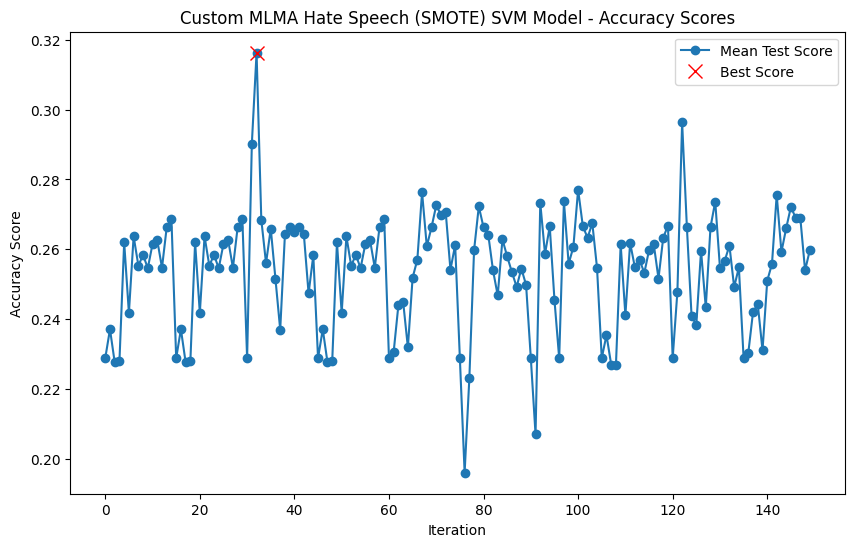

In [178]:
# Plot all accuracy scores for the custom SVM model
plt.figure(figsize=(10, 6))
plt.plot(mlma_hate_speech_custom_svm_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the maximum accuracy score
best_mlma_hate_speech_custom_svm_score_index = np.argmax(mlma_hate_speech_custom_svm_grid_search.cv_results_['mean_test_score'])
plt.plot(best_mlma_hate_speech_custom_svm_score_index, mlma_hate_speech_custom_svm_grid_search.cv_results_['mean_test_score'][best_mlma_hate_speech_custom_svm_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Custom MLMA Hate Speech ({balance}) SVM Model - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [179]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(mlma_hate_speech_custom_svm_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(mlma_hate_speech_custom_svm_grid_search.best_score_)

# Best custom kernel
best_mlma_hate_speech_custom_kernel = mlma_hate_speech_custom_svm_grid_search.best_params_['kernel']

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.30000000000000004),
 'class_weight': None,
 'kernel': 'linear',
 'max_iter': 3}
Best score for SVM with linear kernel and L1 penalty:
0.3162856007245303


In [180]:
# Train the SVM model with the best parameters
mlma_hate_speech_custom_svm_best_params = mlma_hate_speech_custom_svm_grid_search.best_params_.copy()
mlma_hate_speech_custom_svm_best_params.pop('kernel', None) # Remove the kernel key if it exists
mlma_hate_speech_custom_svm_best_model = svm.LinearSVC(**mlma_hate_speech_custom_svm_best_params, random_state=42)
mlma_hate_speech_custom_svm_best_model.fit(mlma_hate_speech_X_train, mlma_hate_speech_y_train)

LinearSVC(C=np.float64(0.30000000000000004), max_iter=3, random_state=42)

In [181]:
# Use the model to make predictions on the test set
mlma_hate_speech_custom_y_pred = mlma_hate_speech_custom_svm_best_model.predict(mlma_hate_speech_X_test)

# Print the classification report
print("Classification report for MLMA Hate Speech Dataset with L1 regularization:")
print(classification_report(mlma_hate_speech_y_test, mlma_hate_speech_custom_y_pred))

Classification report for MLMA Hate Speech Dataset with L1 regularization:
              precision    recall  f1-score   support

           0       0.39      0.50      0.43      2168
           1       0.35      0.23      0.28      2168
           2       0.34      0.17      0.22      2168
           3       0.47      0.72      0.57      2168

    accuracy                           0.40      8672
   macro avg       0.39      0.40      0.38      8672
weighted avg       0.39      0.40      0.38      8672



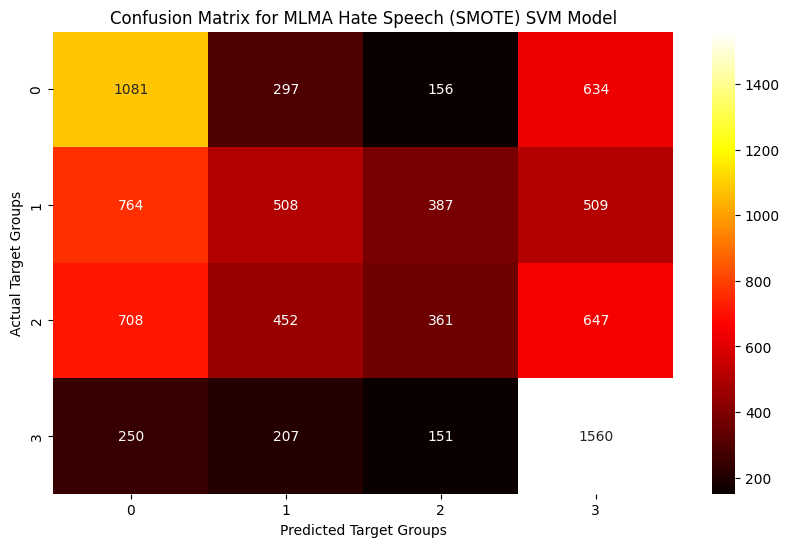

In [182]:
# Plot a heatmap of the predicted vs actual HOF levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(mlma_hate_speech_y_test, mlma_hate_speech_custom_y_pred, rownames=['Actual Target Groups'], colnames=['Predicted Target Groups']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for MLMA Hate Speech ({balance}) SVM Model')
plt.show()

,feature,importance_mean,importance_std
0,implicit,0.049735,0.003542
1,explicit,0.049735,0.003542
2,annotator_sentiment,0.039553,0.002824
3,abuse_level,0.003967,0.002721


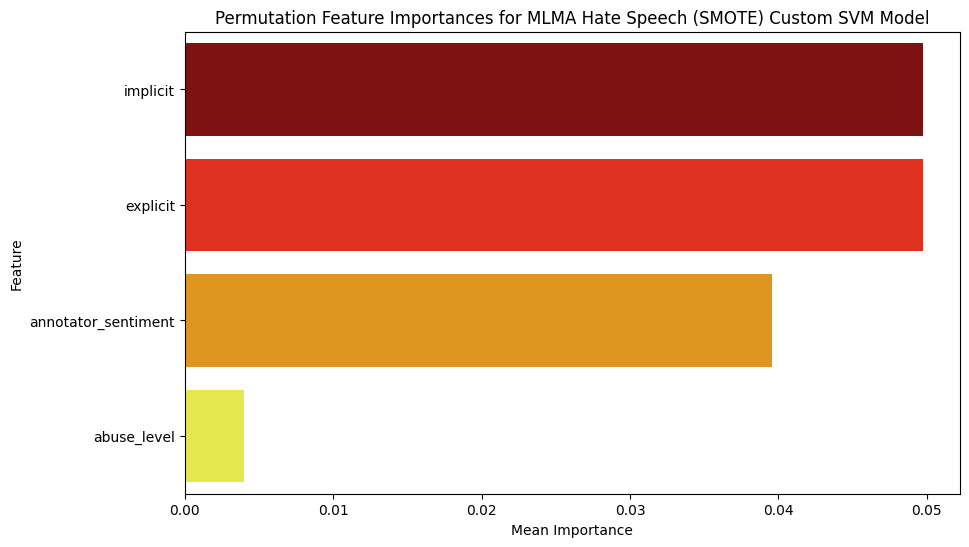

In [183]:
from sklearn.inspection import permutation_importance

# Determine the feature importances using permutation importance
perm_importance = permutation_importance(mlma_hate_speech_custom_svm_best_model, mlma_hate_speech_X_test, mlma_hate_speech_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
mlma_hate_speech_custom_svm_model_perm_importances = pd.DataFrame({
    'feature': mlma_hate_speech_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(mlma_hate_speech_custom_svm_model_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
mlma_hate_speech_custom_svm_model_perm_importances_dict = mlma_hate_speech_custom_svm_model_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=mlma_hate_speech_custom_svm_model_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for MLMA Hate Speech ({balance}) Custom SVM Model')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [184]:
# Get the custom model's accuracy and f1-score
mlma_hate_speech_custom_accuracy = accuracy_score(mlma_hate_speech_y_test, mlma_hate_speech_custom_y_pred)
mlma_hate_speech_custom_f1_score = f1_score(mlma_hate_speech_y_test, mlma_hate_speech_custom_y_pred, average='weighted')
print(f"Custom SVM Model Accuracy: {mlma_hate_speech_custom_accuracy}")
print(f"Custom SVM Model F1-Score: {mlma_hate_speech_custom_f1_score}")

Custom SVM Model Accuracy: 0.4047509225092251
Custom SVM Model F1-Score: 0.37602384525271976


In [185]:
svm_classification_results_list.append(("MLMA Hate Speech", best_mlma_hate_speech_custom_kernel, "L1", mlma_hate_speech_custom_accuracy, mlma_hate_speech_custom_f1_score, mlma_hate_speech_custom_svm_model_perm_importances_dict))

In [186]:
svm_classification_results_list

[('Convabuse',
  'Linear',
  'L1',
  0.546954188611746,
  0.5165317953569895,
  {'explicit': 0.11790718473616224,
   'implicit': 0.10125211169631325,
   'system': 0.09774421146775321,
   'bot': 0.0461691344529465,
   'annotator_id': 0.032127596144291025,
   'target_groups': 0.005346318195369226,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'RBF',
  'L2',
  0.5185332405843188,
  0.4544228996956412,
  {'explicit': 0.1814270098380205,
   'implicit': 0.10783066679916531,
   'bot': 0.045910762198151676,
   'system': 0.038865149557785986,
   'target_groups': 0.029245751763887544,
   'annotator_id': 0.005972374043525808,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'linear',
  'L1',
  0.42700983802047104,
  0.2918535391341153,
  {'explicit': 0.09825101858292758,
   'system': 0.09018185431779788,
   'implicit': 0.027606081685382106,
   'bot': 0.0,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': 0.0,
   'annotator_id': -0.01542283613236609}

## Support Vector Machine Conclusions

In [187]:
# Convert the svm_results_list to a DataFrame
svm_classification_summary = pd.DataFrame(svm_classification_results_list, columns=["Dataset", "Kernel", "Regularization", "Accuracy", "F1 Score", "Permutation Importances"])
svm_classification_summary["Balance"] = "SMOTE"
svm_classification_summary["Model"] = "Support Vector Machine"
svm_classification_summary

,Dataset,Kernel,Regularization,Accuracy,F1 Score,Permutation Importances,Balance,Model
0,Convabuse,Linear,L1,0.546954,0.516532,"{'explicit': 0.11790718473616224, 'implicit': ...",SMOTE,Support Vector Machine
1,Convabuse,RBF,L2,0.518533,0.454423,"{'explicit': 0.1814270098380205, 'implicit': 0...",SMOTE,Support Vector Machine
2,Convabuse,linear,L1,0.427010,0.291854,"{'explicit': 0.09825101858292758, 'system': 0....",SMOTE,Support Vector Machine
3,Dynamically Generated Hate Speech,Linear,L1,0.838416,0.834084,"{'type': 0.33962221210741916, 'annotator': 0.0...",SMOTE,Support Vector Machine
4,Dynamically Generated Hate Speech,RBF,L2,0.820323,0.814329,"{'type': 0.24119253527537549, 'target_groups':...",SMOTE,Support Vector Machine
5,Dynamically Generated Hate Speech,poly,L1,0.574420,0.557631,"{'original': 0.03785844333181608, 'type': 0.02...",SMOTE,Support Vector Machine
6,Online Abusive Attacks,Linear,L1,0.838416,0.834084,"{'type': 0.33962221210741916, 'annotator': 0.0...",SMOTE,Support Vector Machine
7,Online Abusive Attacks,RBF,L2,0.816547,0.814106,"{'Toxic parent tweets': 0.5973920863309353, 'T...",SMOTE,Support Vector Machine
8,Online Abusive Attacks,poly,L1,0.746403,0.687320,"{'Toxic parent tweets': 0.4955035971223022, 'T...",SMOTE,Support Vector Machine
9,US Elections 2020 Election Hate Speech,Linear,L1,0.648674,0.648666,"{'Biden': 0.11609848484848484, 'Trump': 0.0739...",SMOTE,Support Vector Machine


In [188]:
svm_classification_summary.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/model5_svm-classification-summary_SMOTE.csv", index=False)